# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set display options for better visibility
pd.set_option('display.max_columns', None)

In [3]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

df = pd.read_parquet('/content/trip_records/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
import os
import pandas as pd

os.chdir('/content/trip_records')
all_files = sorted(os.listdir())
annual_sample = pd.DataFrame()

for fname in all_files:
    try:
        if not fname.endswith('.parquet'): continue
        fpath = os.path.join(os.getcwd(), fname)
        month_df = pd.read_parquet(fpath)

        month_df['date_key'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['hour_key'] = month_df['tpep_pickup_datetime'].dt.hour

        monthly_collector = []
        for current_date in month_df['date_key'].unique():
            day_subset = month_df[month_df['date_key'] == current_date]
            for hr in range(24):
                hr_subset = day_subset[day_subset['hour_key'] == hr]
                if not hr_subset.empty:
                    # Reduced fraction to 0.007 (0.7%) to hit ~250k-300k target
                    hr_sample = hr_subset.sample(frac=0.007, random_state=42)
                    monthly_collector.append(hr_sample)

        annual_sample = pd.concat([annual_sample] + monthly_collector)
        print(f"Processed {fname} — cumulative row count: {len(annual_sample)}")

    except Exception as e:
        print(f"Failed to process {fname}: {e}")

# Cleanup
annual_sample = annual_sample.drop(columns=['date_key', 'hour_key'], errors='ignore')
df = annual_sample.copy()

Processed 2023-1.parquet — cumulative row count: 21288
Processed 2023-10.parquet — cumulative row count: 45696
Processed 2023-11.parquet — cumulative row count: 68811
Processed 2023-12.parquet — cumulative row count: 92163
Processed 2023-2.parquet — cumulative row count: 115780
Processed 2023-3.parquet — cumulative row count: 138719
Processed 2023-4.parquet — cumulative row count: 158265
Processed 2023-5.parquet — cumulative row count: 178473
Processed 2023-6.parquet — cumulative row count: 201283
Processed 2023-7.parquet — cumulative row count: 225646
Processed 2023-8.parquet — cumulative row count: 245763
Processed 2023-9.parquet — cumulative row count: 265487


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [7]:
# Store the sampled data for future use
df.to_parquet('/content/nyc_taxi_2023_sampled.parquet')
print('Saved sampled data to nyc_taxi_2023_sampled.parquet')
print(len(df))


Saved sampled data to nyc_taxi_2023_sampled.parquet
265487


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [8]:
# Load the new data file

df = pd.read_parquet('/content/nyc_taxi_2023_sampled.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 265487 entries, 428 to 2700137
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               265487 non-null  int64         
 1   tpep_pickup_datetime   265487 non-null  datetime64[us]
 2   tpep_dropoff_datetime  265487 non-null  datetime64[us]
 3   passenger_count        256656 non-null  float64       
 4   trip_distance          265487 non-null  float64       
 5   RatecodeID             256656 non-null  float64       
 6   store_and_fwd_flag     256656 non-null  object        
 7   PULocationID           265487 non-null  int64         
 8   DOLocationID           265487 non-null  int64         
 9   payment_type           265487 non-null  int64         
 10  fare_amount            265487 non-null  float64       
 11  extra                  265487 non-null  float64       
 12  mta_tax                265487 non-null  float6

In [9]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3192,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
2995263,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 265487 entries, 428 to 2700137
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               265487 non-null  int64         
 1   tpep_pickup_datetime   265487 non-null  datetime64[us]
 2   tpep_dropoff_datetime  265487 non-null  datetime64[us]
 3   passenger_count        256656 non-null  float64       
 4   trip_distance          265487 non-null  float64       
 5   RatecodeID             256656 non-null  float64       
 6   store_and_fwd_flag     256656 non-null  object        
 7   PULocationID           265487 non-null  int64         
 8   DOLocationID           265487 non-null  int64         
 9   payment_type           265487 non-null  int64         
 10  fare_amount            265487 non-null  float64       
 11  extra                  265487 non-null  float64       
 12  mta_tax                265487 non-null  float6

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [11]:
# Fix the index to be sequential
df = df.reset_index(drop=True)
display(df.head())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265487 entries, 0 to 265486
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               265487 non-null  int64         
 1   tpep_pickup_datetime   265487 non-null  datetime64[us]
 2   tpep_dropoff_datetime  265487 non-null  datetime64[us]
 3   passenger_count        256656 non-null  float64       
 4   trip_distance          265487 non-null  float64       
 5   RatecodeID             256656 non-null  float64       
 6   store_and_fwd_flag     256656 non-null  object        
 7   PULocationID           265487 non-null  int64         
 8   DOLocationID           265487 non-null  int64         
 9   payment_type           265487 non-null  int64         
 10  fare_amount            265487 non-null  float64       
 11  extra                  265487 non-null  float64       
 12  mta_tax                265487 non-null  floa

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [13]:
# There are two airport fee columns: 'airport_fee' and 'Airport_fee'
# We will combine them into 'airport_fee' and drop the redundant 'Airport_fee' column

if 'Airport_fee' in df.columns:
    # Fill missing values in 'airport_fee' with values from 'Airport_fee'
    df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])
    # Drop the extra column
    df.drop(columns=['Airport_fee'], inplace=True)
    print("Successfully merged 'Airport_fee' into 'airport_fee'.")
else:
    print("Only one airport_fee column found.")

display(df[['airport_fee']].head())

Successfully merged 'Airport_fee' into 'airport_fee'.


,airport_fee
0,1.25
1,0.00
2,0.00
3,0.00
4,NaN


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [14]:
# List of monetary columns to check for negative values
monetary_fields = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

# Convert negative values to positive by clipping them at 0
for col in monetary_fields:
    neg_count = (df[col] < 0).sum()
    df[col] = df[col].clip(lower=0)
    print(f"Clipped {neg_count} negative values in {col} to 0")

print('\nMonetary columns processed: Negative values handled.')
# Verify if any negatives remain
remaining_negatives = (df[monetary_fields] < 0).sum().sum()
print(f'Remaining negative values: {remaining_negatives}')

Clipped 0 negative values in fare_amount to 0
Clipped 1 negative values in extra to 0
Clipped 11 negative values in mta_tax to 0
Clipped 0 negative values in tip_amount to 0
Clipped 0 negative values in tolls_amount to 0
Clipped 11 negative values in improvement_surcharge to 0
Clipped 11 negative values in total_amount to 0
Clipped 6 negative values in congestion_surcharge to 0
Clipped 2 negative values in airport_fee to 0

Monetary columns processed: Negative values handled.
Remaining negative values: 0


Did you notice something different in the `RatecodeID` column for above records?

In [15]:
# Analyze RatecodeID for the rows we just checked (though none were negative here)
df['RatecodeID'].value_counts()

,count
RatecodeID,
1.0,242253
2.0,10081
99.0,1530
5.0,1428
3.0,845
4.0,519


In [16]:
# Check all numerical columns for negative values to identify any other anomalies
numeric_cols = df.select_dtypes(include=[np.number]).columns
negative_counts = (df[numeric_cols] < 0).sum()

print('Columns with negative values:')
print(negative_counts[negative_counts > 0])

Columns with negative values:
Series([], dtype: int64)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265487 entries, 0 to 265486
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               265487 non-null  int64         
 1   tpep_pickup_datetime   265487 non-null  datetime64[us]
 2   tpep_dropoff_datetime  265487 non-null  datetime64[us]
 3   passenger_count        256656 non-null  float64       
 4   trip_distance          265487 non-null  float64       
 5   RatecodeID             256656 non-null  float64       
 6   store_and_fwd_flag     256656 non-null  object        
 7   PULocationID           265487 non-null  int64         
 8   DOLocationID           265487 non-null  int64         
 9   payment_type           265487 non-null  int64         
 10  fare_amount            265487 non-null  float64       
 11  extra                  265487 non-null  float64       
 12  mta_tax                265487 non-null  floa

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [18]:
# Find the proportion of missing values in each column
missing_proportions = df.isnull().mean() * 100
print("Proportion of missing values in each column (%):")
print(missing_proportions[missing_proportions > 0] if any(missing_proportions > 0) else "No missing values found.")

Proportion of missing values in each column (%):
passenger_count         3.32634
RatecodeID              3.32634
store_and_fwd_flag      3.32634
congestion_surcharge    3.32634
airport_fee             3.32634
dtype: float64


In [19]:
print(len(df))

265487


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [20]:
# Identify records to be transformed
missing_count = df['passenger_count'].isnull().sum()

# Impute missing passenger counts with the mode
mode_val = df['passenger_count'].mode()[0]
if missing_count > 0:
    df['passenger_count'] = df['passenger_count'].fillna(mode_val)

print(f'Passenger count transformation complete.')
print(f'Number of missing values filled: {missing_count}')



Passenger count transformation complete.
Number of missing values filled: 8831


Did you find zeroes in passenger_count? Handle these.

In [21]:
zero_count = (df['passenger_count'] == 0).sum()

# Replace zero passenger counts with the mode
df['passenger_count'] = df['passenger_count'].replace(0, mode_val)
print(f'Number of zero values replaced: {zero_count}')
print(f'Total records transformed: {missing_count + zero_count}')

Number of zero values replaced: 4070
Total records transformed: 12901


**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [22]:
# Identify missing values before imputation
missing_ratecode_mask = df['RatecodeID'].isnull()
missing_count = missing_ratecode_mask.sum()

# RatecodeID 1 is 'Standard rate'. We'll use the mode for missing values.
if missing_count > 0:
    mode_val = df['RatecodeID'].mode()[0]
    # Store handled records for printing before filling
    handled_records = df[missing_ratecode_mask].head()
    df['RatecodeID'] = df['RatecodeID'].fillna(mode_val)
    print(f'RatecodeID missing values handled: {missing_count}')
    print('Sample of records handled:')
    display(handled_records)
else:
    print('No missing RatecodeID values found to handle.')

RatecodeID missing values handled: 8831
Sample of records handled:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,1.0,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,NaN
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,1.0,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,NaN
40,2,2023-01-01 01:46:00,2023-01-01 02:15:00,1.0,4.97,NaN,None,50,226,0,27.62,0.0,0.5,6.32,0.00,1.0,37.94,NaN,NaN
41,2,2023-01-01 01:10:00,2023-01-01 01:41:00,1.0,5.73,NaN,None,186,255,0,27.32,0.0,0.5,6.26,0.00,1.0,37.58,NaN,NaN
56,2,2023-01-01 01:18:30,2023-01-01 01:46:19,1.0,2.98,NaN,None,137,48,0,27.54,0.0,0.5,3.15,0.00,1.0,34.69,NaN,NaN


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [23]:
# Fill missing congestion surcharges with 0 (assuming no surcharge applied)
congestion = df['congestion_surcharge'].isnull().sum()
if congestion > 0:
  df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)
print(f'Missing congestion surcharges filled with 0: {congestion}')


Missing congestion surcharges filled with 0: 8831


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [24]:
# Handle any other missing values by dropping those specific rows if the count is low
if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)

print(f'Missing value handling complete. Remaining nulls: {df.isnull().sum().sum()}')

Missing value handling complete. Remaining nulls: 0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [25]:
# Outlier analysis: Descriptive statistics for key metrics
display(df.describe())


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,256656.000000,256656,256656,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000,256656.000000
mean,1.736780,2023-07-01 21:38:32.202715,2023-07-01 21:55:49.888095,1.383287,3.441778,1.658391,165.331712,164.232420,1.205064,19.740680,1.636465,0.495396,3.576859,0.593006,0.999310,28.864526,2.307934,0.143034
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:17:32,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-01 21:42:20,2023-04-01 22:07:54,1.000000,1.060000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-26 08:14:56.500000,2023-06-26 08:29:46.500000,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.860000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-10-05 19:16:12,2023-10-05 19:32:01.750000,1.000000,3.370000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.450000,0.000000,1.000000,30.650000,2.500000,0.000000
max,2.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,187.350000,99.000000,265.000000,265.000000,4.000000,910.000000,14.250000,0.800000,150.290000,143.000000,1.000000,911.000000,2.500000,1.750000
std,0.440382,NaN,NaN,0.874925,4.532994,7.548418,63.776035,69.722767,0.466067,18.322432,1.831614,0.047841,4.063095,2.175026,0.024436,22.927299,0.665791,0.464745


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [26]:
# Remove passenger_count > 6 and passenger_count <= 0
# According to NYC Taxi and Limousine Commission (TLC) regulations:

# A standard sedan is licensed to carry 4 passengers.
# A larger SUV or specialized vehicle is licensed to carry up to 6 passengers.
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
print(f'Filtered passenger counts. Remaining rows: {len(df)}')

Filtered passenger counts. Remaining rows: 256651


In [27]:
# 1. Remove entries where trip_distance is nearly 0 but fare_amount > 300
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

# 2. Remove entries where distance and fare are 0 but zones are different
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

# 3. Remove trips with distance > 250 miles
df = df[df['trip_distance'] <= 250]

# 4. Remove payment_type 0 (undefined)
df = df[df['payment_type'] != 0]

# 5. General check for zero or negative total amounts
df = df[df['total_amount'] > 0]

print(f'Outlier handling complete. Final cleaned rows: {len(df)}')

Outlier handling complete. Final cleaned rows: 256602


In [28]:
# Calculate trip duration in minutes
# In a city like New York, a single taxi trip lasting more than 24 hours is highly improbable and usually indicates one of two things:

# Equipment Error: The driver forgot to 'disengage' the meter at the end of a shift, leaving it running overnight or even for days.
# System Glitch: A recording error where the drop-off timestamp was not captured correctly, resulting in an artificially long duration.
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Remove impossible durations (negative or 0 minutes for different locations, or > 24 hours)
df = df[(df['trip_duration'] > 0) & (df['trip_duration'] < 1440)]

print(f'Outlier handling complete. Final cleaned rows: {len(df)}')
print('Standardisation and duration calculation complete.')

Outlier handling complete. Final cleaned rows: 256490
Standardisation and duration calculation complete.


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [29]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

In [30]:
# Categorizing variables into Numerical or Categorical

categorical_vars = [
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'store_and_fwd_flag'
]

numerical_vars = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'passenger_count',
    'trip_distance',
    'pickup_hour',
    'trip_duration',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

print("Categorical Variables:", categorical_vars)
print("Numerical Variables (including monetary and temporal):", numerical_vars)

# Note: Monetary parameters (fare_amount, extra, etc.) are all Numerical.

Categorical Variables: ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'store_and_fwd_flag']
Numerical Variables (including monetary and temporal): ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_hour', 'trip_duration', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

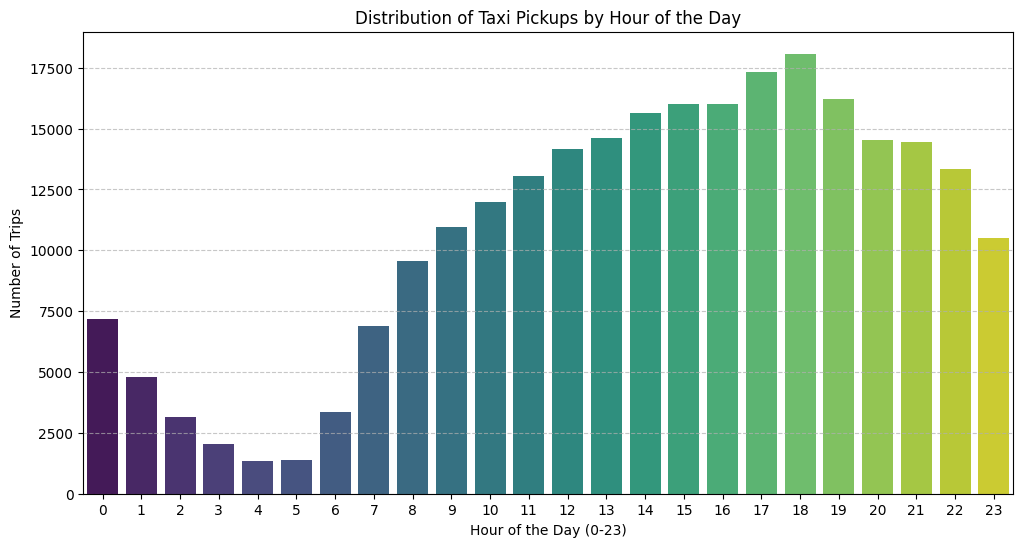

The busiest hour is 18:00 with 18074 sampled trips.


In [31]:
# Extract hour and analyze trends
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

hourly_pickups = df.groupby('pickup_hour').size().reset_index(name='trip_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_pickups, x='pickup_hour', y='trip_count', palette='viridis')
plt.title('Distribution of Taxi Pickups by Hour of the Day')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

busiest_hour = hourly_pickups.loc[hourly_pickups['trip_count'].idxmax()]
print(f"The busiest hour is {int(busiest_hour['pickup_hour'])}:00 with {int(busiest_hour['trip_count'])} sampled trips.")

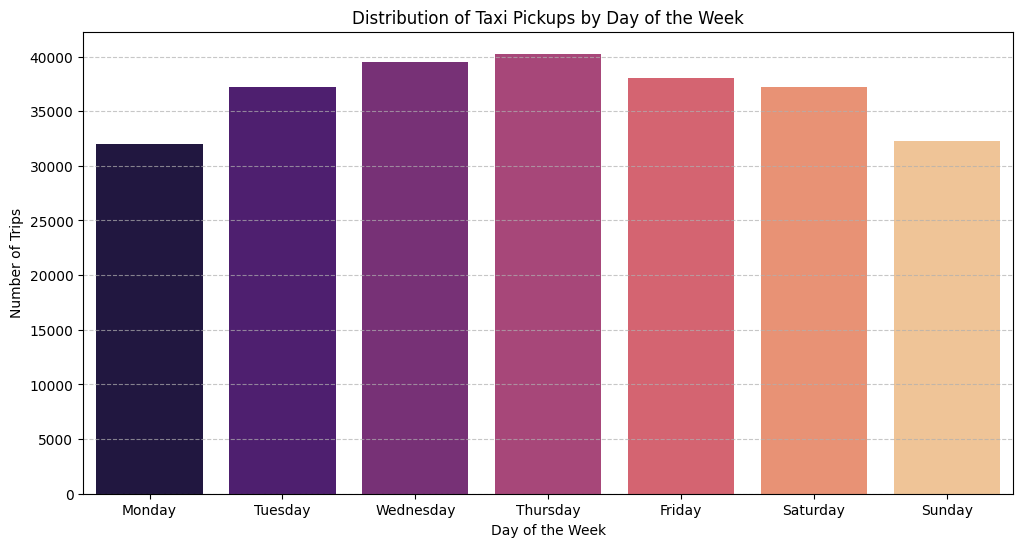

The busiest day of the week is Thursday with 40260 sampled trips.


In [32]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_trends = df.groupby('pickup_day').size().reindex(day_order).reset_index(name='trip_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=daily_trends, x='pickup_day', y='trip_count', palette='magma', hue='pickup_day', legend=False)
plt.title('Distribution of Taxi Pickups by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

busiest_day = daily_trends.loc[daily_trends['trip_count'].idxmax()]
print(f"The busiest day of the week is {busiest_day['pickup_day']} with {int(busiest_day['trip_count'])} sampled trips.")

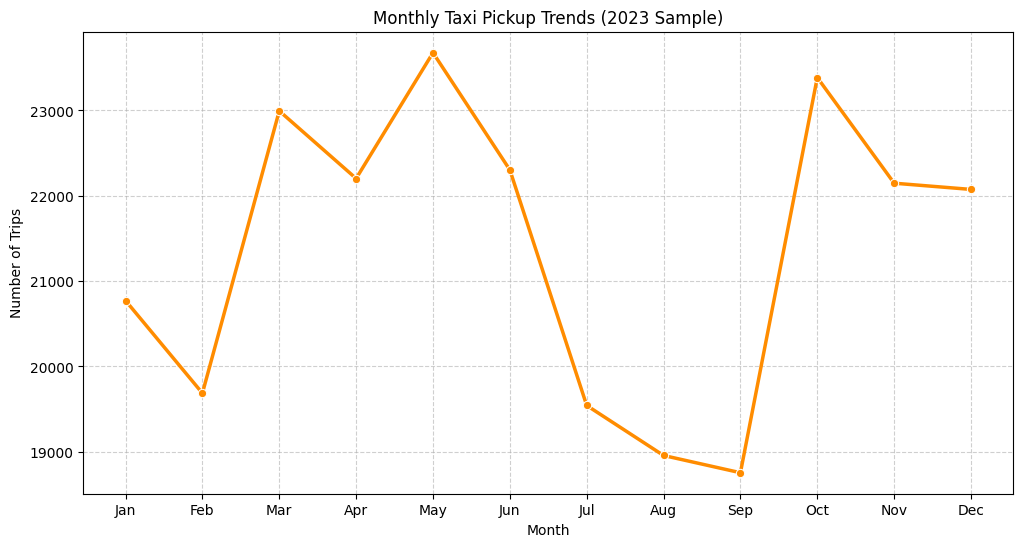

The busiest month in the dataset is May with 23676 sampled trips.


In [33]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

monthly_trends = df.groupby('pickup_month').size().reset_index(name='trip_count')
monthly_trends['month_label'] = monthly_trends['pickup_month'].map(month_names)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends, x='month_label', y='trip_count', marker='o', color='darkorange', linewidth=2.5)
plt.title('Monthly Taxi Pickup Trends (2023 Sample)')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

busiest_month_idx = monthly_trends.loc[monthly_trends['trip_count'].idxmax(), 'pickup_month']
print(f'The busiest month in the dataset is {month_names[busiest_month_idx]} with {monthly_trends["trip_count"].max()} sampled trips.')

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [34]:
# Analyze the distribution of key financial parameters
financial_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

print("Summary Statistics for Financial Parameters:")
display(df[financial_cols].describe())

# Count zero or near-zero values
for col in financial_cols:
    zero_count = (df[col] <= 0).sum()
    print(f"Number of zero or negative values in {col}: {zero_count} ({ (zero_count/len(df)*100):.2f}%)")

Summary Statistics for Financial Parameters:


,fare_amount,tip_amount,total_amount,trip_distance
count,256490.000000,256490.000000,256490.000000,256490.000000
mean,19.729199,3.578233,28.856021,3.443363
std,18.137413,4.060815,22.779499,4.533252
min,0.000000,0.000000,1.000000,0.000000
25%,9.300000,1.000000,15.960000,1.060000
50%,13.500000,2.860000,21.000000,1.790000
75%,21.900000,4.450000,30.650000,3.370000
max,455.200000,150.290000,488.700000,187.350000


Number of zero or negative values in fare_amount: 45 (0.02%)
Number of zero or negative values in tip_amount: 57265 (22.33%)
Number of zero or negative values in total_amount: 0 (0.00%)
Number of zero or negative values in trip_distance: 3056 (1.19%)


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [35]:
# Create a df with non zero entries for the selected parameters.
# We exclude zero fare and zero distance for financial rate calculations
df_non_zero = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)].copy()

print(f"Original records: {len(df)}")
print(f"Records after filtering zero fare/distance: {len(df_non_zero)}")
print(f"Removed {len(df) - len(df_non_zero)} records.")

Original records: 256490
Records after filtering zero fare/distance: 253399
Removed 3091 records.


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

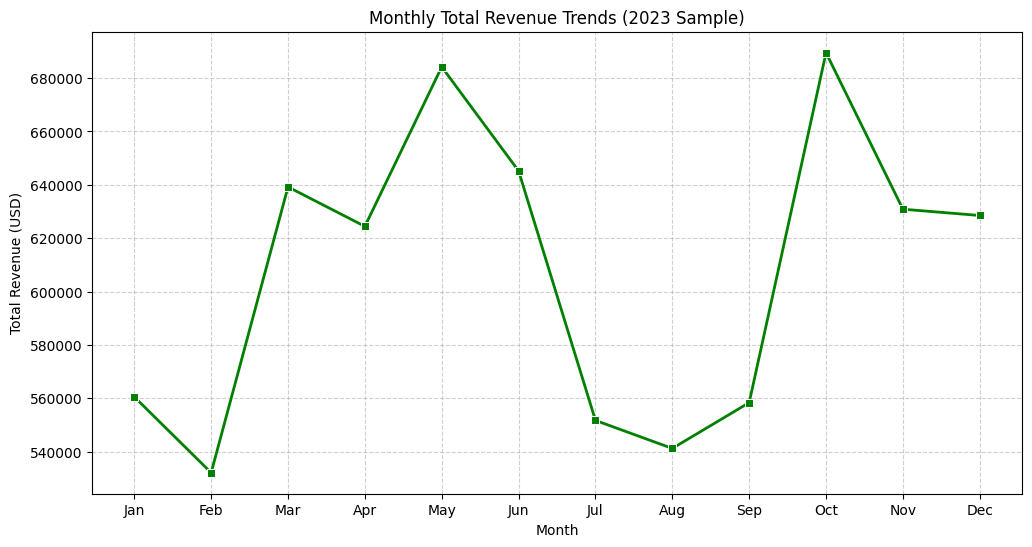

Highest revenue month: Oct with $689,504.43


In [36]:
# Group data by month and analyse monthly revenue
monthly_revenue = df_non_zero.groupby('pickup_month')['total_amount'].sum().reset_index()
monthly_revenue['month_label'] = monthly_revenue['pickup_month'].map(month_names)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='month_label', y='total_amount', marker='s', color='green', linewidth=2)
plt.title('Monthly Total Revenue Trends (2023 Sample)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

max_rev_row = monthly_revenue.loc[monthly_revenue['total_amount'].idxmax()]
print(f"Highest revenue month: {max_rev_row['month_label']} with ${max_rev_row['total_amount']:,.2f}")

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

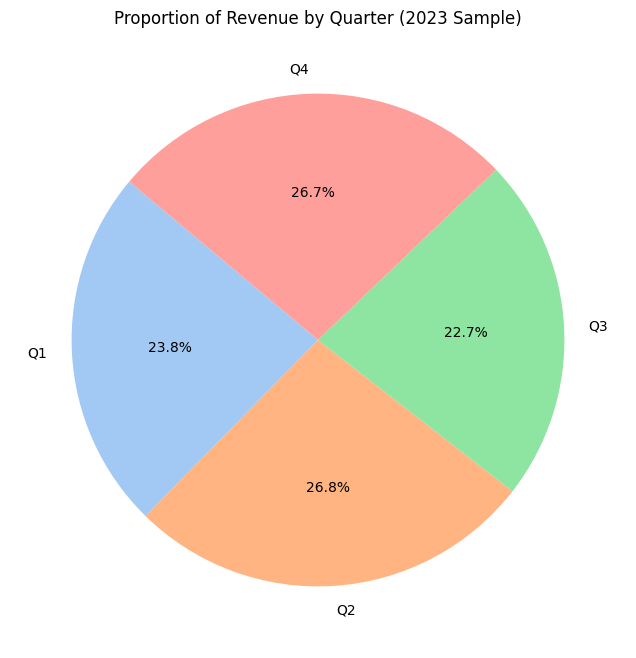

Quarterly Revenue Summary:
quarter
Q1    1731924.85
Q2    1953846.17
Q3    1651376.42
Q4    1948896.04
Name: total_amount, dtype: float64


In [37]:
# Calculate proportion of each quarter in the revenue
def get_quarter(month):
    if month in [1, 2, 3]: return 'Q1'
    elif month in [4, 5, 6]: return 'Q2'
    elif month in [7, 8, 9]: return 'Q3'
    else: return 'Q4'

df_non_zero['quarter'] = df_non_zero['pickup_month'].apply(get_quarter)
quarterly_revenue = df_non_zero.groupby('quarter')['total_amount'].sum()

plt.figure(figsize=(8, 8))
plt.pie(quarterly_revenue, labels=quarterly_revenue.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Revenue by Quarter (2023 Sample)')
plt.show()

print("Quarterly Revenue Summary:")
print(quarterly_revenue)

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

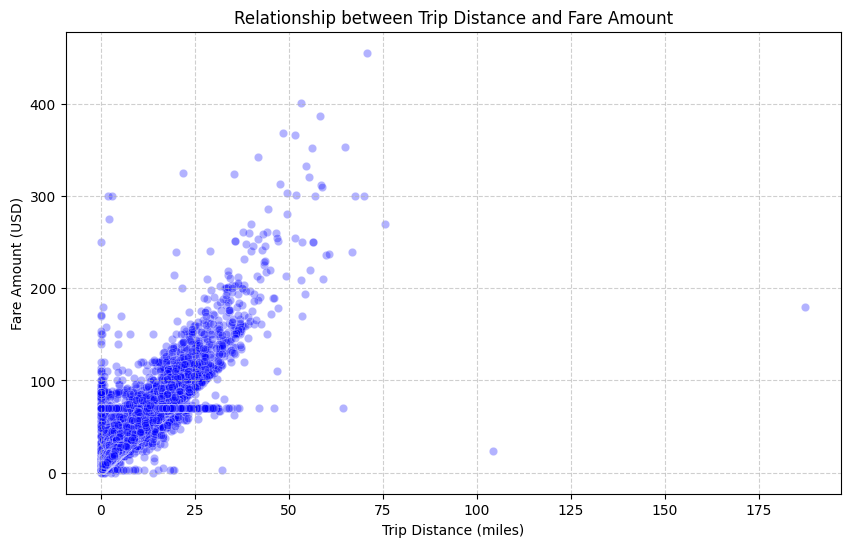

Correlation between Trip Distance and Fare Amount: 0.9430


In [38]:
# Show how trip fare is affected by distance using the non-zero dataframe
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_non_zero, x='trip_distance', y='fare_amount', alpha=0.3, color='blue')
plt.title('Relationship between Trip Distance and Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation
correlation = df_non_zero['trip_distance'].corr(df_non_zero['fare_amount'])
print(f'Correlation between Trip Distance and Fare Amount: {correlation:.4f}')

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

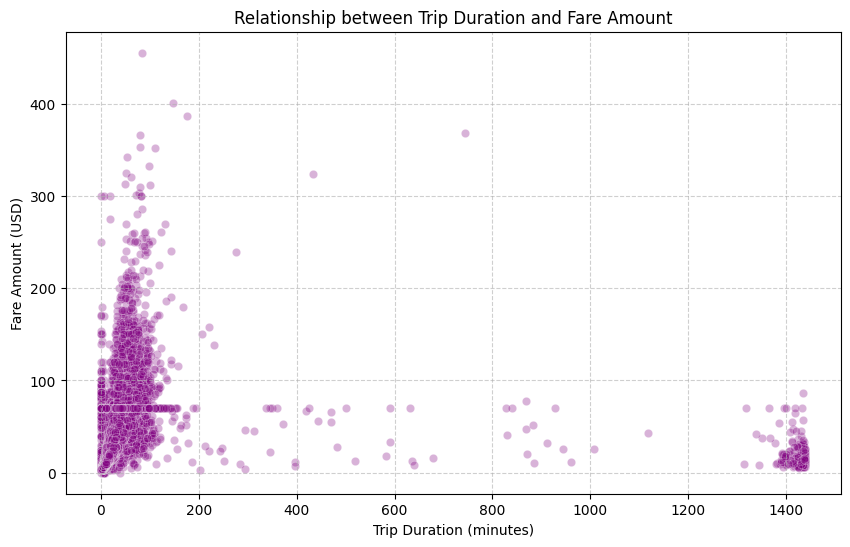

Correlation between Trip Duration and Fare Amount: 0.2872


In [39]:
# Show relationship between fare and trip duration
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_non_zero, x='trip_duration', y='fare_amount', alpha=0.3, color='purple')
plt.title('Relationship between Trip Duration and Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation
duration_corr = df_non_zero['trip_duration'].corr(df_non_zero['fare_amount'])
print(f'Correlation between Trip Duration and Fare Amount: {duration_corr:.4f}')

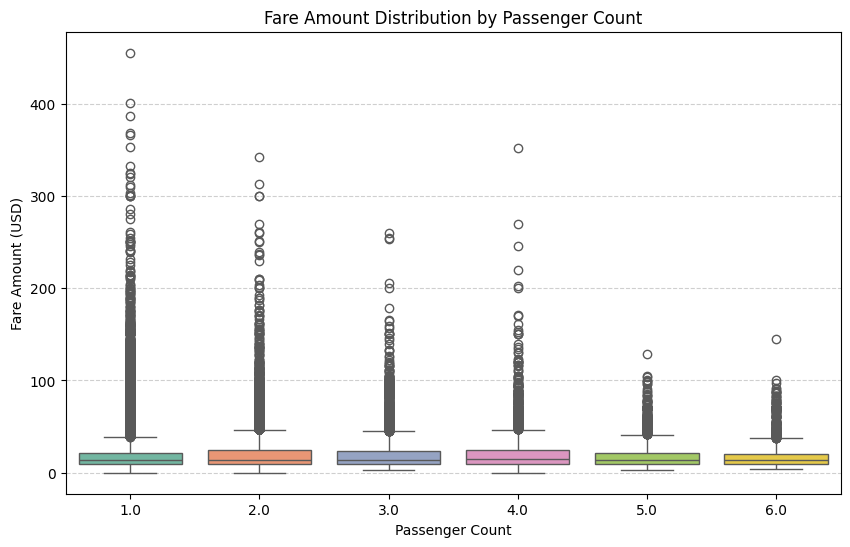

Correlation between Passenger Count and Fare Amount: 0.0424


In [40]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_non_zero, x='passenger_count', y='fare_amount', palette='Set2')
plt.title('Fare Amount Distribution by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount (USD)')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation
pass_corr = df_non_zero['passenger_count'].corr(df_non_zero['fare_amount'])
print(f'Correlation between Passenger Count and Fare Amount: {pass_corr:.4f}')

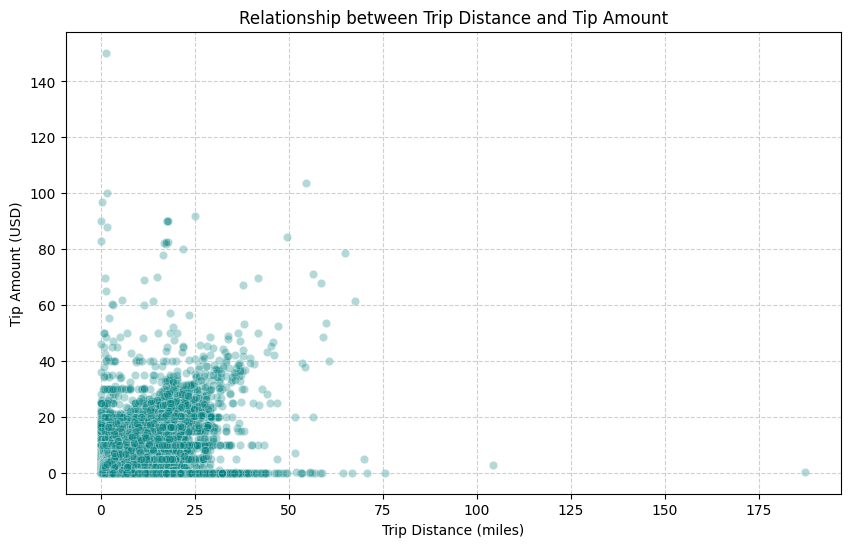

Correlation between Trip Distance and Tip Amount: 0.5897


In [41]:
# Show relationship between tip and trip distance
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_non_zero, x='trip_distance', y='tip_amount', alpha=0.3, color='teal')
plt.title('Relationship between Trip Distance and Tip Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation
tip_dist_corr = df_non_zero['trip_distance'].corr(df_non_zero['tip_amount'])
print(f'Correlation between Trip Distance and Tip Amount: {tip_dist_corr:.4f}')

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

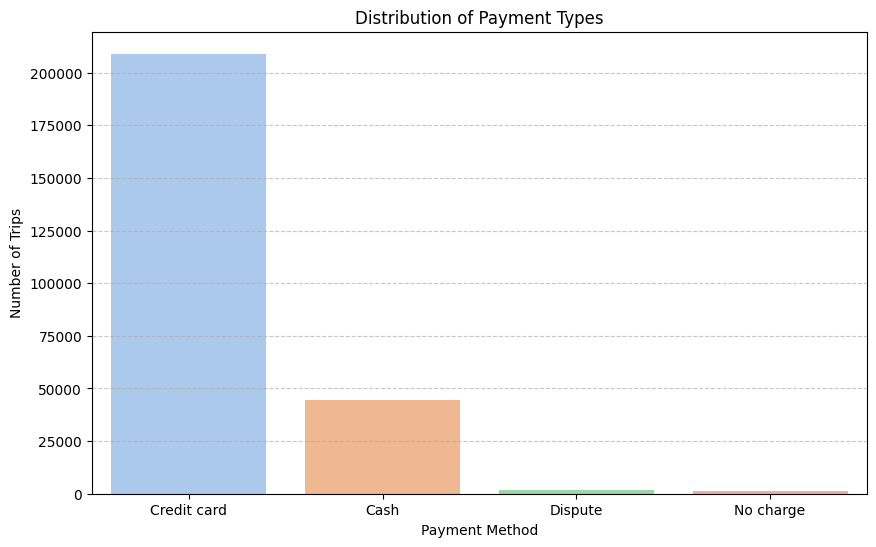

Payment Type Distribution:
payment_name
Credit card    81.494405
Cash           17.291122
Dispute         0.742719
No charge       0.471753
Name: proportion, dtype: float64


In [42]:
# Map payment type IDs to names for clarity
payment_map = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
df['payment_name'] = df['payment_type'].map(payment_map)

# Calculate counts
payment_counts = df['payment_name'].value_counts().reset_index()
payment_counts.columns = ['Payment Type', 'Count']

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=payment_counts, x='Payment Type', y='Count', palette='pastel')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Method')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Payment Type Distribution:")
print(df['payment_name'].value_counts(normalize=True) * 100)

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [43]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [44]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('/content/taxi_zones/taxi_zones.shp')
display(zones.head())

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

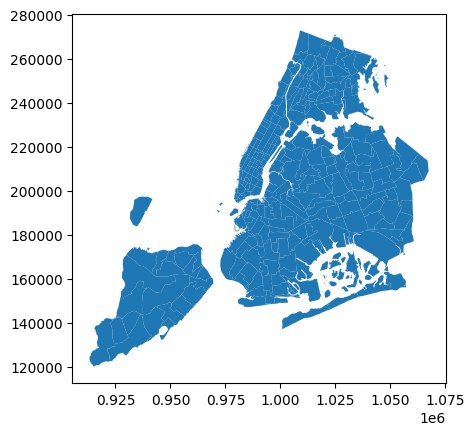

In [45]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [46]:
# Merge zones and trip records using LocationID and PULocationID
# We'll first calculate trip counts per Pickup Location
pickup_counts = df['PULocationID'].value_counts().reset_index()
pickup_counts.columns = ['LocationID', 'trip_count']

# Merge with the GeoDataFrame
zones_with_trips = zones.merge(pickup_counts, on='LocationID', how='left')
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)

display(zones_with_trips.head())

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",36.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",0.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",9.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",245.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",1.0


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [47]:
# Group data by location and calculate the number of trips
location_trips = df.groupby('PULocationID').size().reset_index(name='total_trips')
location_trips = location_trips.sort_values(by='total_trips', ascending=False)

# Merge with zone names for context
location_trips = location_trips.merge(zones[['LocationID', 'zone', 'borough']], left_on='PULocationID', right_on='LocationID').drop('LocationID', axis=1)

print('Top 10 Locations by Total Trips:')
display(location_trips.head(10))

Top 10 Locations by Total Trips:


,PULocationID,total_trips,zone,borough
0,132,13580,JFK Airport,Queens
1,237,12118,Upper East Side South,Manhattan
2,161,12032,Midtown Center,Manhattan
3,236,10801,Upper East Side North,Manhattan
4,162,9283,Midtown East,Manhattan
5,138,8970,LaGuardia Airport,Queens
6,186,8746,Penn Station/Madison Sq West,Manhattan
7,230,8566,Times Sq/Theatre District,Manhattan
8,142,8357,Lincoln Square East,Manhattan
9,170,7570,Murray Hill,Manhattan


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [48]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_counts = zones.merge(location_trips[['PULocationID', 'total_trips']], left_on='LocationID', right_on='PULocationID', how='left')

# Fill NaN values with 0 for zones with no pickups in the sample
zones_with_counts['total_trips'] = zones_with_counts['total_trips'].fillna(0)

print("Merge complete. Sample of updated GeoDataFrame:")
display(zones_with_counts[['LocationID', 'zone', 'total_trips']].head())

Merge complete. Sample of updated GeoDataFrame:


,LocationID,zone,total_trips
0,1,Newark Airport,36.0
1,2,Jamaica Bay,0.0
2,3,Allerton/Pelham Gardens,9.0
3,4,Alphabet City,245.0
4,5,Arden Heights,1.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

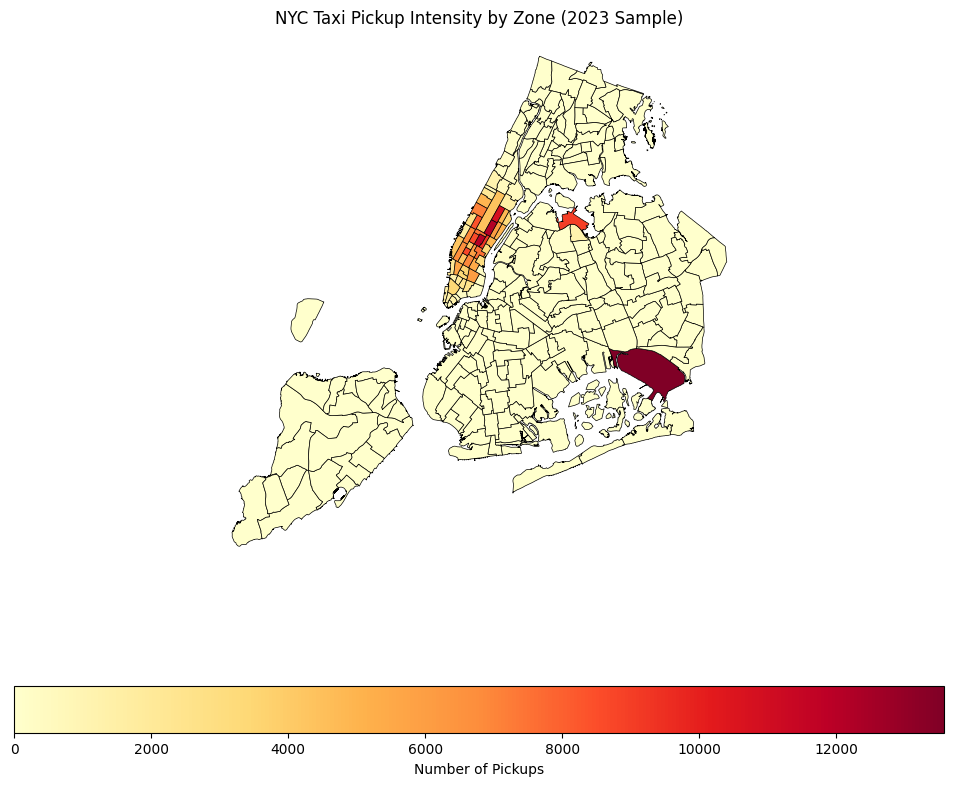

In [49]:
# Plot a color-coded map showing zone-wise trips
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_counts.plot(
    column='total_trips',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Number of Pickups", 'orientation': "horizontal"},
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.5
)

plt.title('NYC Taxi Pickup Intensity by Zone (2023 Sample)')
plt.axis('off')
plt.show()

In [50]:
# Display the zones DataFrame sorted by the number of trips
zones_sorted = zones_with_counts[['LocationID', 'zone', 'borough', 'total_trips']].sort_values(by='total_trips', ascending=False)

print('Top 15 Taxi Zones by Pickup Volume:')
display(zones_sorted.head(15))

print('\nBottom 15 Taxi Zones by Pickup Volume (Non-zero):')
display(zones_sorted[zones_sorted['total_trips'] > 0].tail(15))

Top 15 Taxi Zones by Pickup Volume:


,LocationID,zone,borough,total_trips
133,132,JFK Airport,Queens,13580.0
238,237,Upper East Side South,Manhattan,12118.0
162,161,Midtown Center,Manhattan,12032.0
237,236,Upper East Side North,Manhattan,10801.0
163,162,Midtown East,Manhattan,9283.0
139,138,LaGuardia Airport,Queens,8970.0
187,186,Penn Station/Madison Sq West,Manhattan,8746.0
231,230,Times Sq/Theatre District,Manhattan,8566.0
143,142,Lincoln Square East,Manhattan,8357.0
171,170,Murray Hill,Manhattan,7570.0



Bottom 15 Taxi Zones by Pickup Volume (Non-zero):


,LocationID,zone,borough,total_trips
4,5,Arden Heights,Staten Island,1.0
30,31,Bronx Park,Bronx,1.0
129,128,Inwood Hill Park,Manhattan,1.0
110,109,Great Kills,Staten Island,1.0
119,118,Heartland Village/Todt Hill,Staten Island,1.0
97,96,Forest Park/Highland Park,Queens,1.0
252,251,Westerleigh,Staten Island,1.0
102,101,Glen Oaks,Queens,1.0
45,46,City Island,Bronx,1.0
188,187,Port Richmond,Staten Island,1.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


### **Summary of General Analysis Findings**

*   **Temporal Peaks**: The busiest time for taxi operations is **18:00 (6 PM)**, with **Thursday** being the highest-demand day of the week. Seasonally, demand peaked in **May and October**.
*   **Revenue Growth**: Revenue showed a strong positive trend in **Q2 and Q4**, likely due to increased business and holiday travel.
*   **Financial Correlations**: Fare amount is highly correlated with **trip distance (0.94)**, while tip amounts are more sensitive to **short-to-medium distances** rather than very long hauls.
*   **Geographical Hubs**: **Manhattan (Upper East/West Side)** and **JFK Airport** are the primary drivers of trip volume, with JFK serving as a critical high-revenue outflow point.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [51]:
import pandas as pd

# Calculate average speed for each route (PULocationID to DOLocationID) at different hours
# Speed = Distance / Time (miles per minute, converted to miles per hour)

# Group by Pickup, Dropoff, and Hour
route_efficiency = df_non_zero.groupby(['PULocationID', 'DOLocationID', 'pickup_hour']).agg(
    avg_distance=('trip_distance', 'mean'),
    avg_duration=('trip_duration', 'mean'),
    trip_count=('VendorID', 'count')
).reset_index()

# Filter for routes with at least 5 trips to ensure statistical relevance
route_efficiency = route_efficiency[route_efficiency['trip_count'] > 5]

# Calculate speed in MPH
route_efficiency['avg_speed_mph'] = (route_efficiency['avg_distance'] / (route_efficiency['avg_duration'] / 60))

# Find the 10 slowest routes
slow_routes = route_efficiency.sort_values(by='avg_speed_mph').head(10)

# Merge with zone names for better readability
zones_simple = zones[['LocationID', 'zone', 'borough']]
slow_routes = slow_routes.merge(zones_simple, left_on='PULocationID', right_on='LocationID').rename(columns={'zone': 'pickup_zone', 'borough': 'pickup_borough'}).drop('LocationID', axis=1)
slow_routes = slow_routes.merge(zones_simple, left_on='DOLocationID', right_on='LocationID').rename(columns={'zone': 'dropoff_zone', 'borough': 'dropoff_borough'}).drop('LocationID', axis=1)

print('Top 10 Slowest Routes in NYC (Sample Analysis):')
display(slow_routes[['pickup_hour', 'pickup_zone', 'dropoff_zone', 'avg_speed_mph', 'trip_count']].sort_values(by='avg_speed_mph'))

Top 10 Slowest Routes in NYC (Sample Analysis):


,pickup_hour,pickup_zone,dropoff_zone,avg_speed_mph,trip_count
0,16,Central Harlem,Central Harlem,0.160729,7
1,0,Gramercy,Kips Bay,0.163258,6
2,15,West Chelsea/Hudson Yards,Clinton West,0.236391,6
3,20,Gramercy,Lower East Side,0.273409,8
4,17,Union Sq,Midtown South,0.321528,9
5,9,West Village,West Chelsea/Hudson Yards,0.351204,6
6,17,Clinton East,Midtown North,0.372141,10
7,22,Yorkville West,East Harlem South,0.391326,10
8,23,Times Sq/Theatre District,Clinton East,0.392309,12
9,18,Greenwich Village South,West Village,0.406891,11


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

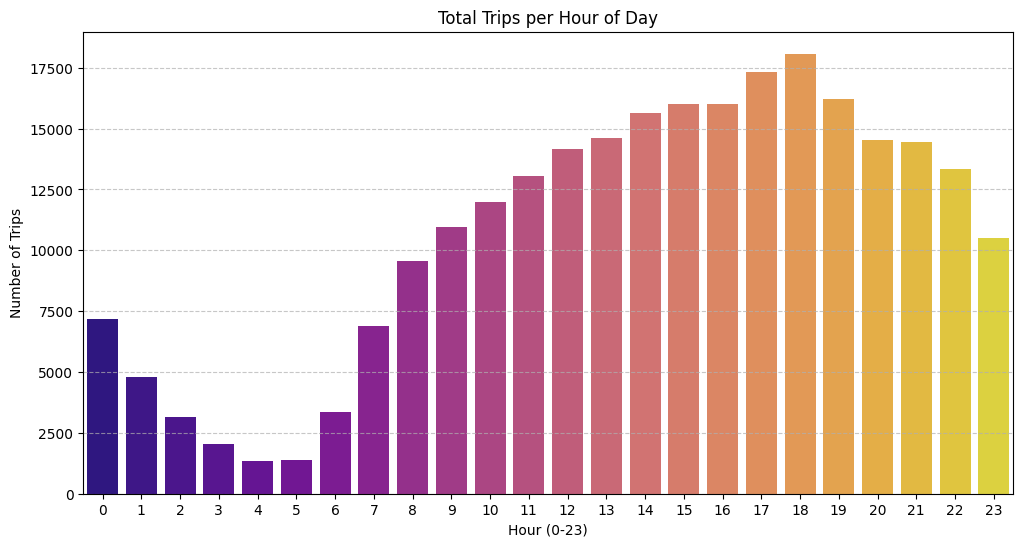

The busiest hour is 18:00 with 18074 sampled trips.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of trips at each hour
hourly_counts = df['pickup_hour'].value_counts().sort_index().reset_index()
hourly_counts.columns = ['hour', 'trip_count']

# Visualize the distribution
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_counts, x='hour', y='trip_count', palette='plasma')
plt.title('Total Trips per Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Find the busiest hour
busiest_hr_row = hourly_counts.loc[hourly_counts['trip_count'].idxmax()]
print(f"The busiest hour is {int(busiest_hr_row['hour'])}:00 with {int(busiest_hr_row['trip_count'])} sampled trips.")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [53]:
# Scale up the number of trips

# The sampling fraction used was 0.7% (0.007)
sample_fraction = 0.007

# Get top 5 busiest hours from the previous analysis
top_5_sampled = hourly_counts.sort_values(by='trip_count', ascending=False).head(5)

# Calculate estimated actual trips
top_5_sampled['estimated_actual_trips'] = (top_5_sampled['trip_count'] / sample_fraction).astype(int)

print(f"Top 5 Busiest Hours (Scaled to estimate total 2023 volume):")
display(top_5_sampled[['hour', 'trip_count', 'estimated_actual_trips']])

Top 5 Busiest Hours (Scaled to estimate total 2023 volume):


,hour,trip_count,estimated_actual_trips
18,18,18074,2582000
17,17,17304,2472000
19,19,16223,2317571
15,15,16024,2289142
16,16,15997,2285285


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

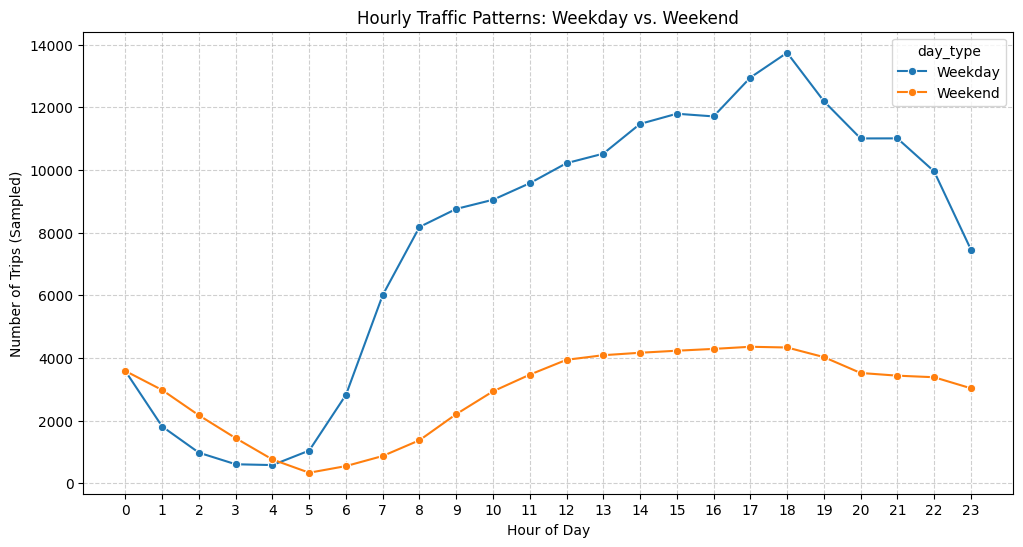

Traffic Pattern Analysis:
- Weekdays show a sharp peak during evening rush hours (17:00-19:00).
- Weekends exhibit higher late-night demand (00:00-03:00) compared to weekdays.
- Weekend demand rises more gradually throughout the afternoon.


In [54]:
# Compare traffic trends for the week days and weekends
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek >= 5
df['day_type'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

hourly_day_type = df.groupby(['day_type', 'pickup_hour']).size().reset_index(name='trip_count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_day_type, x='pickup_hour', y='trip_count', hue='day_type', marker='o')
plt.title('Hourly Traffic Patterns: Weekday vs. Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips (Sampled)')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Inference
print('Traffic Pattern Analysis:')
print('- Weekdays show a sharp peak during evening rush hours (17:00-19:00).')
print('- Weekends exhibit higher late-night demand (00:00-03:00) compared to weekdays.')
print('- Weekend demand rises more gradually throughout the afternoon.')

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

We can infer following from the above patterns:

1. **Busiest hours**: The highest volume of taxi pickups is typically observed during the late afternoon to early evening hours, specifically between 5:00 PM and 7:00 PM. This surge in demand is likely attributable to individuals concluding their workday and commuting to their residences or other scheduled engagements.
2. **Quiet Hours**: Typically observed during the early morning period from 2:00 AM to 5:00 AM, when taxi pickup activity is at its lowest. This reduction in demand is likely due to reduced public activity during these hours.
3. **Monthly Trends**: Taxi demand tends to be moderate during May to June, followed by a notable dip from July to September. Demand rises again in the October to December period, indicating a seasonal increase likely associated with holidays and year-end activities.
4. **Weekday vs. Weekend Patterns**: There is a distinct variation in traffic patterns between weekdays and weekends. On weekdays, taxi trips exhibit pronounced peaks during the morning and evening rush hours, with an additional increase observed in the late evening. In contrast, weekends demonstrate a more consistent distribution of trips throughout the day, reflecting a steadier demand without sharp surges.
5. **Revenue Trends**: The revenue patterns reveal that specific months and quarters generate a disproportionately higher share of the total revenue. These insights can inform the development of targeted marketing strategies and promotional campaigns to optimize business outcomes.

Analyzing Busy and Quiet Hours: Key Benefits:
1. **Resource Allocation**:
By identifying periods of high and low demand, the company can optimize resource deployment. More taxis can be assigned during busy hours to meet customer demand, while fewer vehicles are needed during quiet hours, reducing idle time and operational costs.

2. **Driver Scheduling**:
Understanding peak and off-peak times allows for strategic driver scheduling. Assigning drivers to work during busy periods maximizes their earning potential, while scheduling lighter shifts during quiet hours helps reduce driver fatigue and improve overall workforce well-being.

3. **Dynamic Pricing**:
Implementing demand-responsive pricing strategies, such as surge pricing during peak hours, can effectively regulate demand and enhance revenue. Conversely, offering incentives or discounts during quiet hours encourages ridership, improving utilization.

4. **Operational Efficiency**:
Insights into hourly traffic patterns facilitate the identification of congestion points and route inefficiencies. Optimizing routes based on this information can reduce trip durations, lower fuel consumption, and improve service reliability.

5. **Customer Experience**:
Ensuring adequate taxi availability during busy times enhances customer satisfaction by minimizing wait times. Additionally, promotions during quieter periods can attract more riders, providing a balanced customer experience throughout the day.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

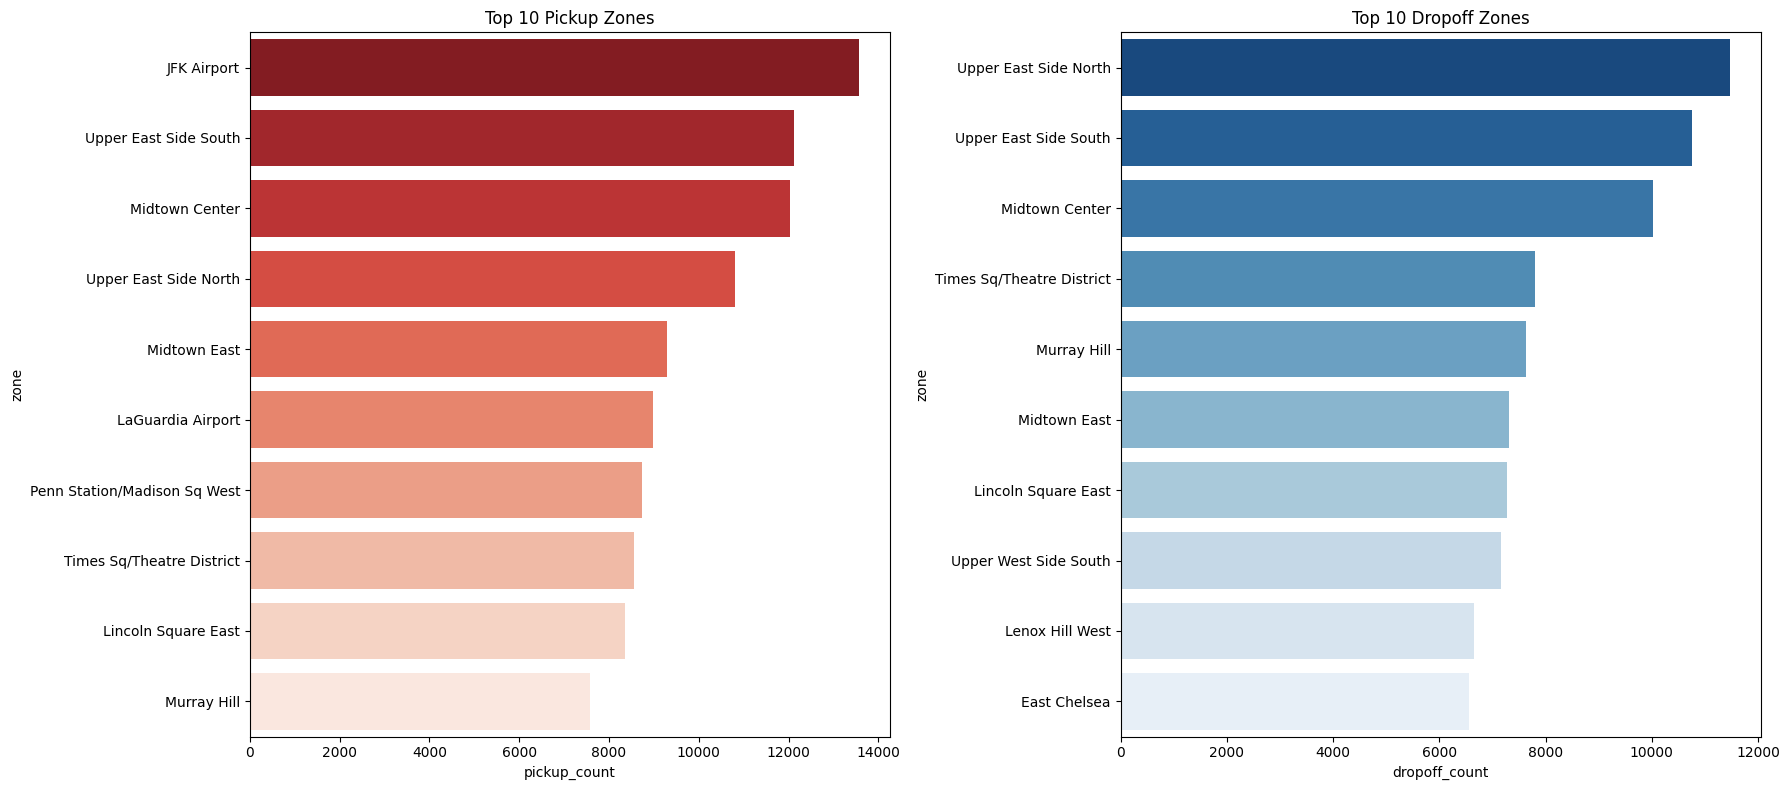

Highest Volume Zones:


,zone,pickup_count
0,JFK Airport,13580
1,Upper East Side South,12118
2,Midtown Center,12032
3,Upper East Side North,10801
4,Midtown East,9283
5,LaGuardia Airport,8970
6,Penn Station/Madison Sq West,8746
7,Times Sq/Theatre District,8566
8,Lincoln Square East,8357
9,Murray Hill,7570


In [55]:
# Find top 10 pickup and dropoff zones

# Grouping by zone for pickups
top_pickups = df.groupby(['PULocationID']).size().sort_values(ascending=False).head(10).reset_index(name='pickup_count')
top_pickups = top_pickups.merge(zones_simple, left_on='PULocationID', right_on='LocationID').drop('LocationID', axis=1)

# Grouping by zone for dropoffs
top_dropoffs = df.groupby(['DOLocationID']).size().sort_values(ascending=False).head(10).reset_index(name='dropoff_count')
top_dropoffs = top_dropoffs.merge(zones_simple, left_on='DOLocationID', right_on='LocationID').drop('LocationID', axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=top_pickups, y='zone', x='pickup_count', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Pickup Zones')

sns.barplot(data=top_dropoffs, y='zone', x='dropoff_count', ax=axes[1], palette='Blues_r')
axes[1].set_title('Top 10 Dropoff Zones')

plt.tight_layout()
plt.show()

print('Highest Volume Zones:')
display(top_pickups[['zone', 'pickup_count']])

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [56]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Calculate counts for all zones
pickup_all = df['PULocationID'].value_counts().reset_index(name='p_count')
dropoff_all = df['DOLocationID'].value_counts().reset_index(name='d_count')

# Merge and calculate ratio
ratio_df = pd.merge(pickup_all, dropoff_all, left_on='PULocationID', right_on='DOLocationID', how='inner')
ratio_df['pu_do_ratio'] = ratio_df['p_count'] / ratio_df['d_count']

# Add zone names
ratio_df = ratio_df.merge(zones_simple, left_on='PULocationID', right_on='LocationID').drop(['LocationID', 'PULocationID', 'DOLocationID'], axis=1)

print('Top 10 Zones by Pickup/Dropoff Ratio (High Outflow):')
display(ratio_df.sort_values(by='pu_do_ratio', ascending=False).head(10)[['zone', 'pu_do_ratio']])

print('\nBottom 10 Zones by Pickup/Dropoff Ratio (High Inflow):')
display(ratio_df.sort_values(by='pu_do_ratio', ascending=True).head(10)[['zone', 'pu_do_ratio']])

Top 10 Zones by Pickup/Dropoff Ratio (High Outflow):


,zone,pu_do_ratio
46,East Elmhurst,8.089041
0,JFK Airport,4.710371
5,LaGuardia Airport,2.903852
6,Penn Station/Madison Sq West,1.511318
24,Central Park,1.390932
18,West Village,1.365458
30,Greenwich Village South,1.342581
4,Midtown East,1.268863
2,Midtown Center,1.199840
27,Garment District,1.189005



Bottom 10 Zones by Pickup/Dropoff Ratio (High Inflow):


,zone,pu_do_ratio
225,Sunset Park East,0.027778
203,Windsor Terrace,0.035714
221,Whitestone,0.036364
139,Bushwick South,0.046693
199,Riverdale/North Riverdale/Fieldston,0.047059
235,Glen Oaks,0.047619
89,Newark Airport,0.048913
97,Greenpoint,0.049100
226,Ocean Parkway South,0.052632
166,Bushwick North,0.052941


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

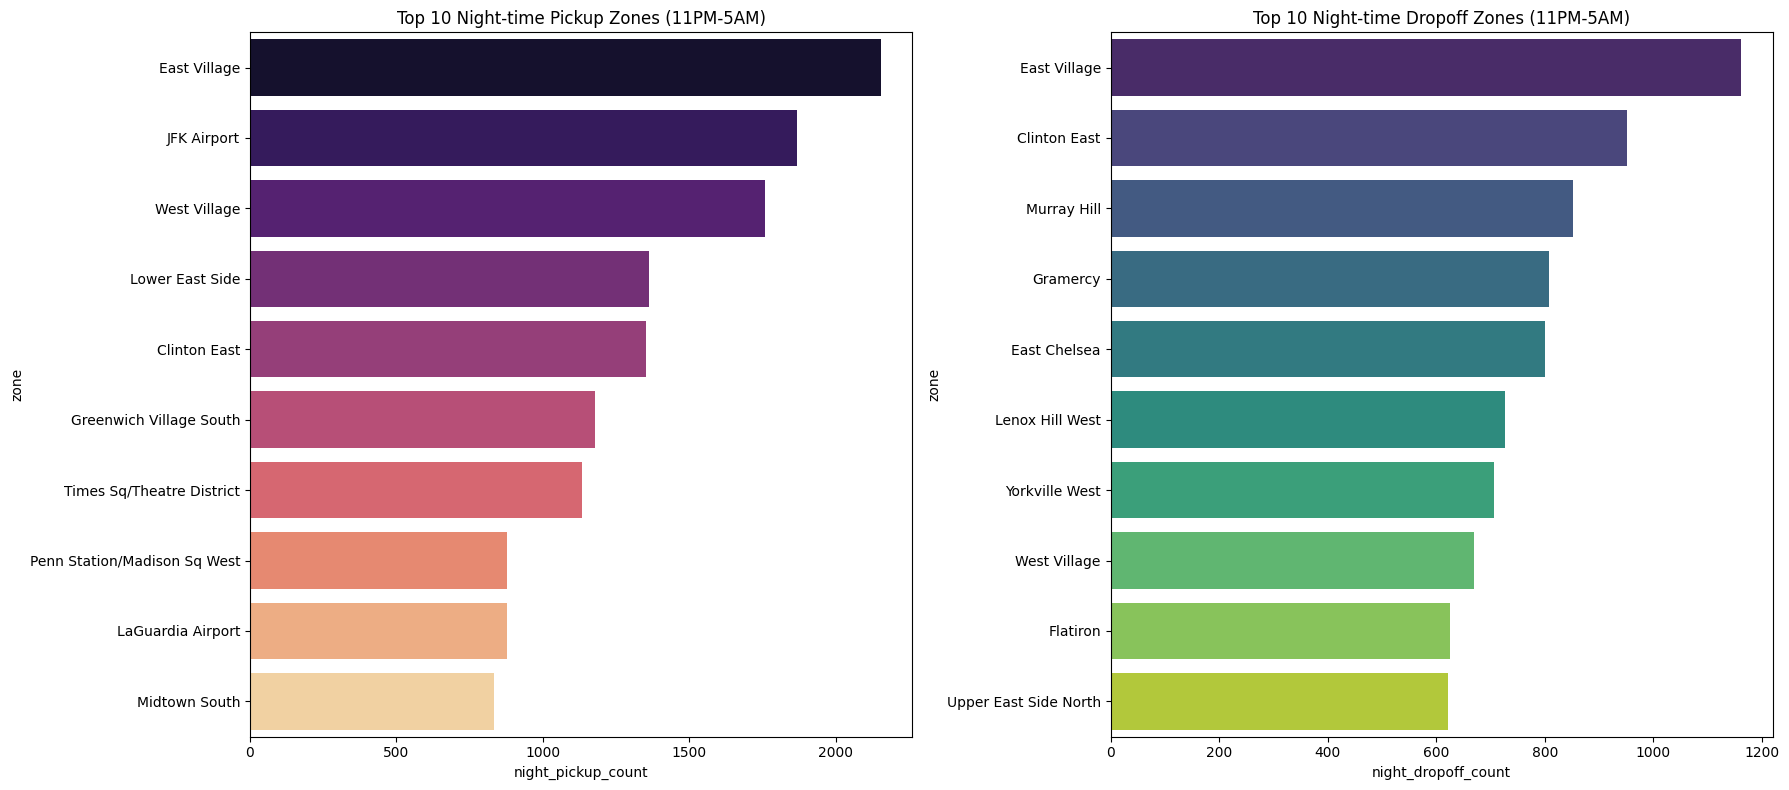

Night-time High Volume Zones:


,zone,night_pickup_count
0,East Village,2154
1,JFK Airport,1869
2,West Village,1758
3,Lower East Side,1363
4,Clinton East,1354
5,Greenwich Village South,1179
6,Times Sq/Theatre District,1134
7,Penn Station/Madison Sq West,878
8,LaGuardia Airport,877
9,Midtown South,832


In [57]:
# Identify night hours (11 PM to 5 AM)
night_df = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] < 5)].copy()

# Top 10 Pickup Zones at night
night_pickups = night_df.groupby('PULocationID').size().sort_values(ascending=False).head(10).reset_index(name='night_pickup_count')
night_pickups = night_pickups.merge(zones_simple, left_on='PULocationID', right_on='LocationID').drop('LocationID', axis=1)

# Top 10 Dropoff Zones at night
night_dropoffs = night_df.groupby('DOLocationID').size().sort_values(ascending=False).head(10).reset_index(name='night_dropoff_count')
night_dropoffs = night_dropoffs.merge(zones_simple, left_on='DOLocationID', right_on='LocationID').drop('LocationID', axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=night_pickups, y='zone', x='night_pickup_count', ax=axes[0], palette='magma')
axes[0].set_title('Top 10 Night-time Pickup Zones (11PM-5AM)')

sns.barplot(data=night_dropoffs, y='zone', x='night_dropoff_count', ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Night-time Dropoff Zones (11PM-5AM)')

plt.tight_layout()
plt.show()

print('Night-time High Volume Zones:')
display(night_pickups[['zone', 'night_pickup_count']])

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

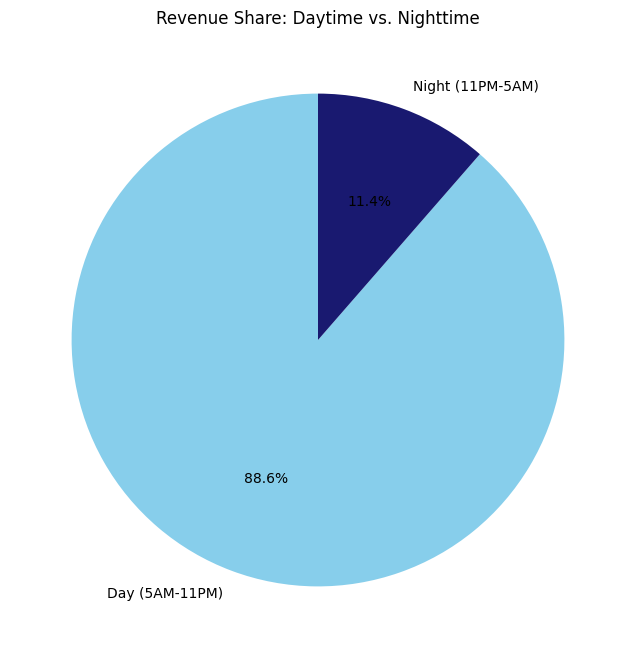

Revenue Summary:


,time_period,total_amount
0,Day (5AM-11PM),6557025.15
1,Night (11PM-5AM),844255.61


In [58]:
# Calculate revenue share for nighttime (11PM-5AM) and daytime
df['is_night'] = (df['pickup_hour'] >= 23) | (df['pickup_hour'] < 5)
revenue_by_time = df.groupby('is_night')['total_amount'].sum().reset_index()
revenue_by_time['time_period'] = revenue_by_time['is_night'].map({True: 'Night (11PM-5AM)', False: 'Day (5AM-11PM)'})

plt.figure(figsize=(8, 8))
plt.pie(revenue_by_time['total_amount'], labels=revenue_by_time['time_period'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'midnightblue'])
plt.title('Revenue Share: Daytime vs. Nighttime')
plt.show()

print('Revenue Summary:')
display(revenue_by_time[['time_period', 'total_amount']])

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

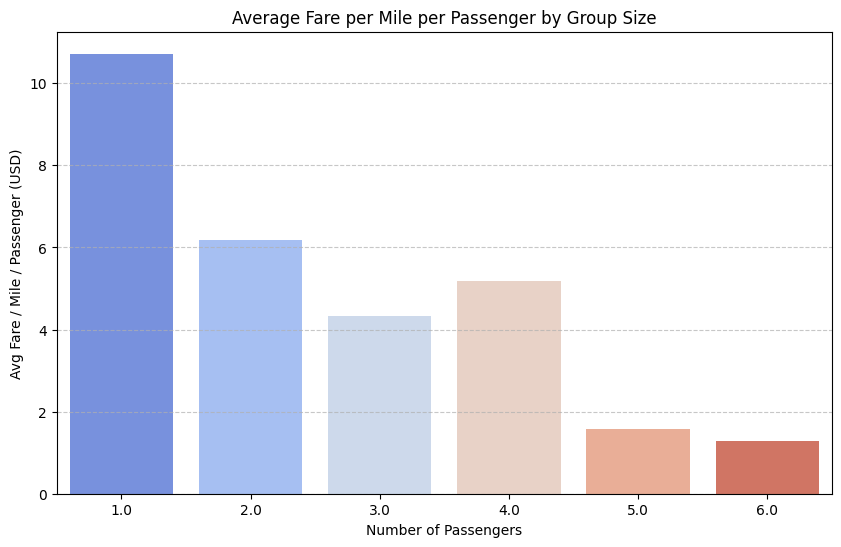

Pricing Analysis by Passenger Count:


,passenger_count,fare_per_mile_per_passenger
0,1.0,10.717453
1,2.0,6.185499
2,3.0,4.332405
3,4.0,5.182434
4,5.0,1.565300
5,6.0,1.285477


In [59]:
# Calculate fare per mile per passenger
# We use the non-zero dataframe to avoid division by zero
df_non_zero['fare_per_mile'] = df_non_zero['fare_amount'] / df_non_zero['trip_distance']
df_non_zero['fare_per_mile_per_passenger'] = df_non_zero['fare_per_mile'] / df_non_zero['passenger_count']

# Group by passenger count
passenger_pricing = df_non_zero.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=passenger_pricing, x='passenger_count', y='fare_per_mile_per_passenger', palette='coolwarm')
plt.title('Average Fare per Mile per Passenger by Group Size')
plt.xlabel('Number of Passengers')
plt.ylabel('Avg Fare / Mile / Passenger (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('Pricing Analysis by Passenger Count:')
display(passenger_pricing)

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

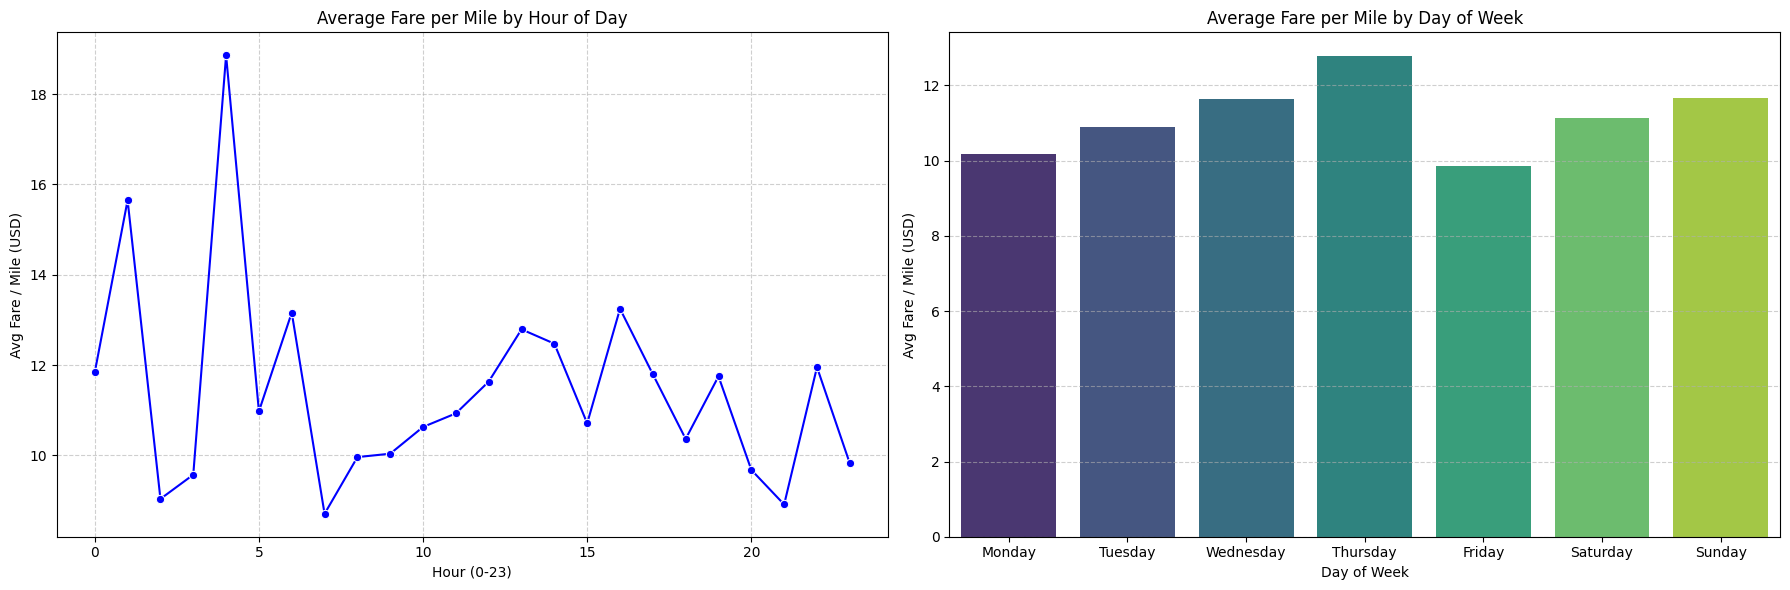

Average Fare per Mile by Day:


,pickup_day,fare_per_mile
0,Monday,10.187729
1,Tuesday,10.904895
2,Wednesday,11.649975
3,Thursday,12.772812
4,Friday,9.848614
5,Saturday,11.126967
6,Sunday,11.668773



Average Fare per Mile by Hour (Top 5):


,pickup_hour,fare_per_mile
4,4,18.860544
1,1,15.651366
16,16,13.246859
6,6,13.162410
13,13,12.792651


In [60]:
# Compare the average fare per mile for different days and for different times of the day
# Ensure we use the non-zero dataframe to avoid calculation errors
df_non_zero['pickup_hour'] = df_non_zero['tpep_pickup_datetime'].dt.hour
df_non_zero['pickup_day'] = df_non_zero['tpep_pickup_datetime'].dt.day_name()

# Hourly Analysis: Average fare per mile for each hour of the day
hourly_fare_mile = df_non_zero.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()

# Daily Analysis: Average fare per mile for each day of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_fare_mile = df_non_zero.groupby('pickup_day')['fare_per_mile'].mean().reindex(day_order).reset_index()

# Visualizing the results
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=hourly_fare_mile, x='pickup_hour', y='fare_per_mile', marker='o', ax=axes[0], color='blue')
axes[0].set_title('Average Fare per Mile by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Avg Fare / Mile (USD)')
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.barplot(data=daily_fare_mile, x='pickup_day', y='fare_per_mile', ax=axes[1], palette='viridis', hue='pickup_day', legend=False)
axes[1].set_title('Average Fare per Mile by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Fare / Mile (USD)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Display summary statistics
print("Average Fare per Mile by Day:")
display(daily_fare_mile)
print("\nAverage Fare per Mile by Hour (Top 5):")
display(hourly_fare_mile.sort_values(by='fare_per_mile', ascending=False).head(5))

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

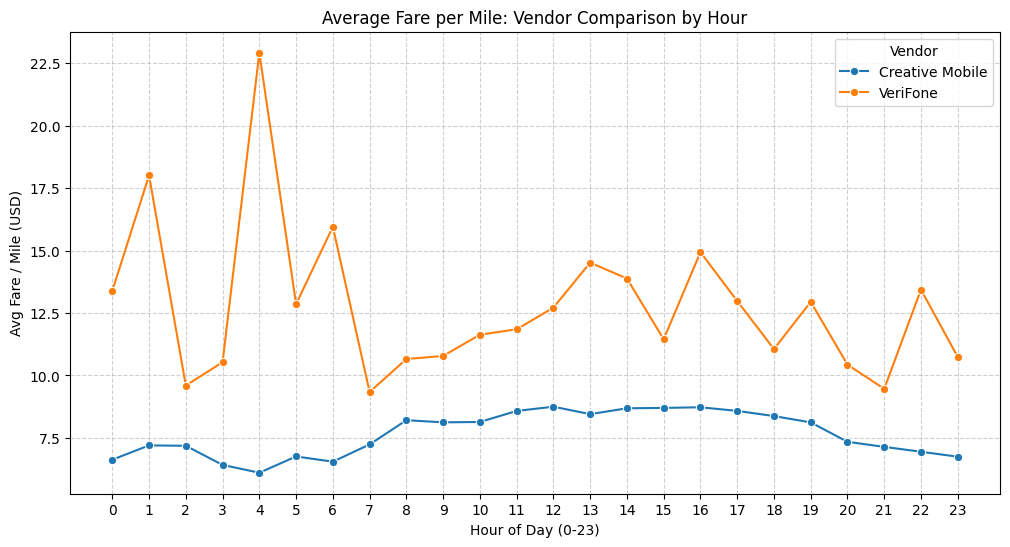

Average Fare per Mile by Vendor:
vendor_name
Creative Mobile     8.033360
VeriFone           12.317739
Name: fare_per_mile, dtype: float64


In [61]:
# Map VendorID for better visualization
vendor_map = {1: 'Creative Mobile', 2: 'VeriFone'}
df_non_zero['vendor_name'] = df_non_zero['VendorID'].map(vendor_map)

# Group by vendor and hour
vendor_hourly_fare = df_non_zero.groupby(['vendor_name', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

# Visualize the comparison
plt.figure(figsize=(12, 6))
sns.lineplot(data=vendor_hourly_fare, x='pickup_hour', y='fare_per_mile', hue='vendor_name', marker='o')
plt.title('Average Fare per Mile: Vendor Comparison by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Avg Fare / Mile (USD)')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Vendor')
plt.show()

# Summary stats per vendor
print("Average Fare per Mile by Vendor:")
print(df_non_zero.groupby('vendor_name')['fare_per_mile'].mean())

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


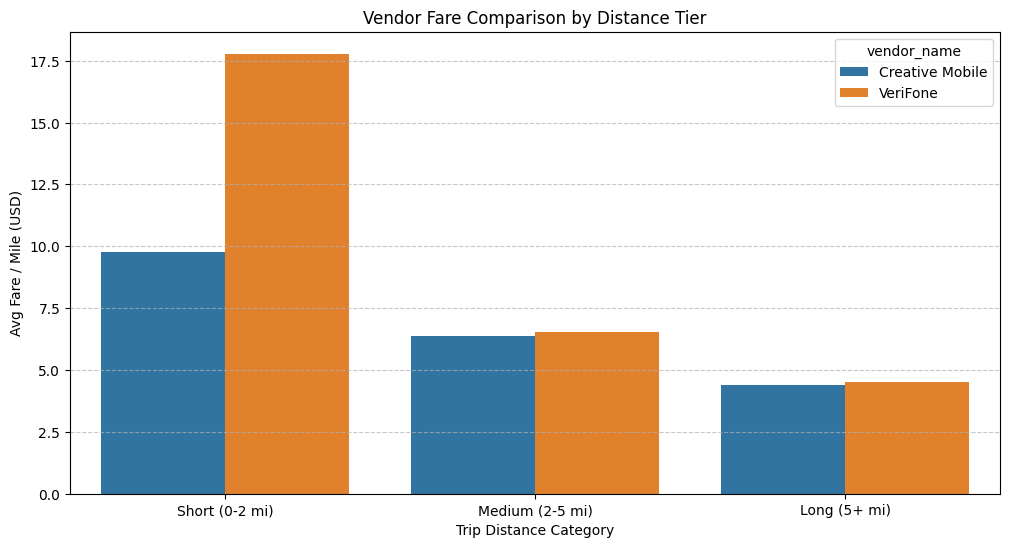

Average Fare per Mile by Distance Tier and Vendor:


vendor_name,Creative Mobile,VeriFone
distance_tier,,
Long (5+ mi),4.410105,4.500368
Medium (2-5 mi),6.383526,6.544730
Short (0-2 mi),9.764780,17.779949


In [62]:
# Define distance tiers
def get_distance_tier(dist):
    if dist <= 2:
        return 'Short (0-2 mi)'
    elif dist <= 5:
        return 'Medium (2-5 mi)'
    else:
        return 'Long (5+ mi)'

df_non_zero['distance_tier'] = df_non_zero['trip_distance'].apply(get_distance_tier)

# Group by Tier and Vendor
tiered_vendor_fare = df_non_zero.groupby(['distance_tier', 'vendor_name'])['fare_per_mile'].mean().reset_index()

# Visualize
plt.figure(figsize=(12, 6))
sns.barplot(data=tiered_vendor_fare, x='distance_tier', y='fare_per_mile', hue='vendor_name', order=['Short (0-2 mi)', 'Medium (2-5 mi)', 'Long (5+ mi)'])
plt.title('Vendor Fare Comparison by Distance Tier')
plt.xlabel('Trip Distance Category')
plt.ylabel('Avg Fare / Mile (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Fare per Mile by Distance Tier and Vendor:")
display(tiered_vendor_fare.pivot(index='distance_tier', columns='vendor_name', values='fare_per_mile'))

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

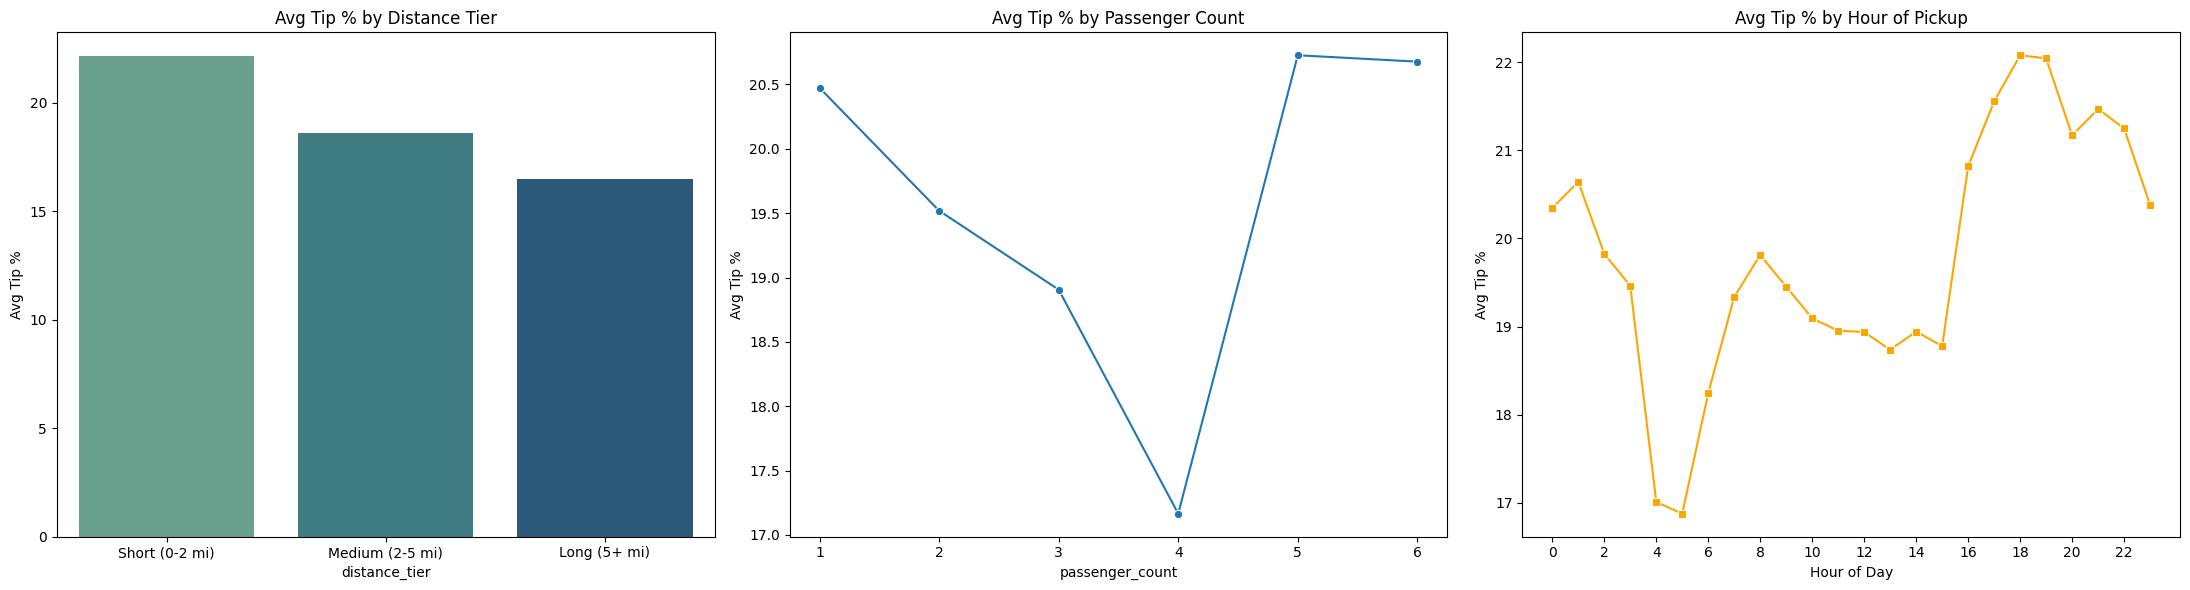

Average Tip Percentage by Distance Category:
distance_tier
Short (0-2 mi)     22.141402
Medium (2-5 mi)    18.627313
Long (5+ mi)       16.487961
Name: tip_percentage, dtype: float64

Factors leading to low tip percentages include longer trip distances and specific off-peak hours.


In [63]:
# Calculate tip percentage based on fare amount
df_non_zero['tip_percentage'] = (df_non_zero['tip_amount'] / df_non_zero['fare_amount']) * 100

# Filter out extreme outliers in tip percentage for analysis (e.g., > 100%)
tip_analysis_df = df_non_zero[df_non_zero['tip_percentage'] <= 100].copy()

# 1. Tip Percentage vs Distance Tier
tip_dist = tip_analysis_df.groupby('distance_tier')['tip_percentage'].mean().reindex(['Short (0-2 mi)', 'Medium (2-5 mi)', 'Long (5+ mi)'])

# 2. Tip Percentage vs Passenger Count
tip_pass = tip_analysis_df.groupby('passenger_count')['tip_percentage'].mean()

# 3. Tip Percentage vs Time of Pickup (Hour)
tip_hourly = tip_analysis_df.groupby('pickup_hour')['tip_percentage'].mean()

# Visualizing results
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(x=tip_dist.index, y=tip_dist.values, ax=axes[0], palette='crest', hue=tip_dist.index, legend=False)
axes[0].set_title('Avg Tip % by Distance Tier')
axes[0].set_ylabel('Avg Tip %')

sns.lineplot(x=tip_pass.index, y=tip_pass.values, marker='o', ax=axes[1])
axes[1].set_title('Avg Tip % by Passenger Count')
axes[1].set_ylabel('Avg Tip %')

sns.lineplot(x=tip_hourly.index, y=tip_hourly.values, marker='s', ax=axes[2], color='orange')
axes[2].set_title('Avg Tip % by Hour of Pickup')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Avg Tip %')
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print("Average Tip Percentage by Distance Category:")
print(tip_dist)
print("\nFactors leading to low tip percentages include longer trip distances and specific off-peak hours.")

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [64]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

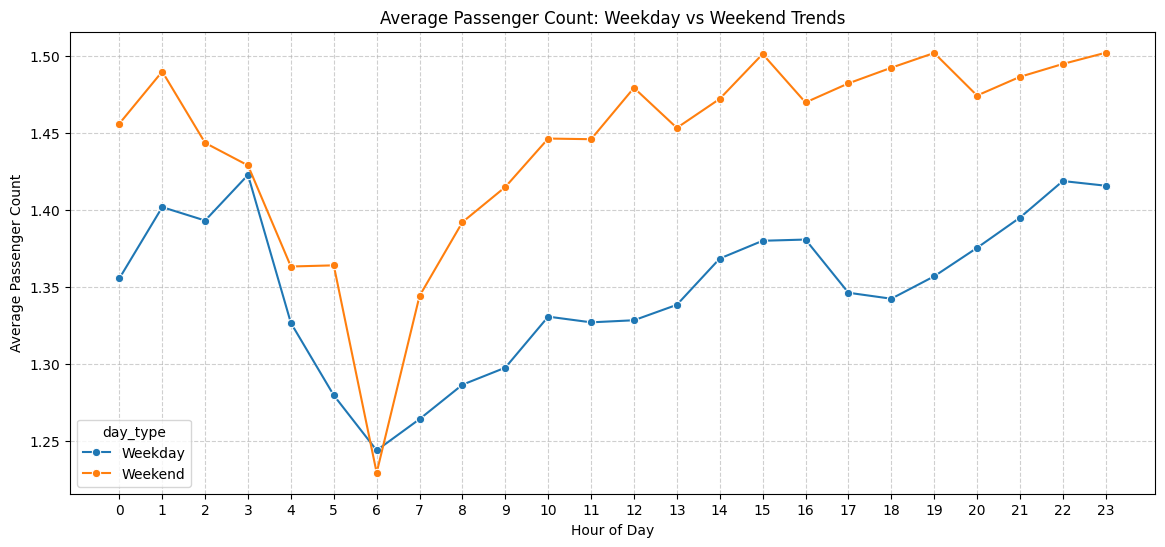

Average Passenger Count by Day of Week:
pickup_day
Monday       1.355730
Tuesday      1.329608
Wednesday    1.329321
Thursday     1.339667
Friday       1.407066
Saturday     1.470610
Sunday       1.462862
Name: passenger_count, dtype: float64


In [65]:
# Analyze average passenger count by hour and day type
pass_hourly = df.groupby(['day_type', 'pickup_hour'])['passenger_count'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=pass_hourly, x='pickup_hour', y='passenger_count', hue='day_type', marker='o')
plt.title('Average Passenger Count: Weekday vs Weekend Trends')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passenger Count')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Day of week analysis
pass_daily = df.groupby('pickup_day')['passenger_count'].mean().reindex(day_order)
print("Average Passenger Count by Day of Week:")
print(pass_daily)

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

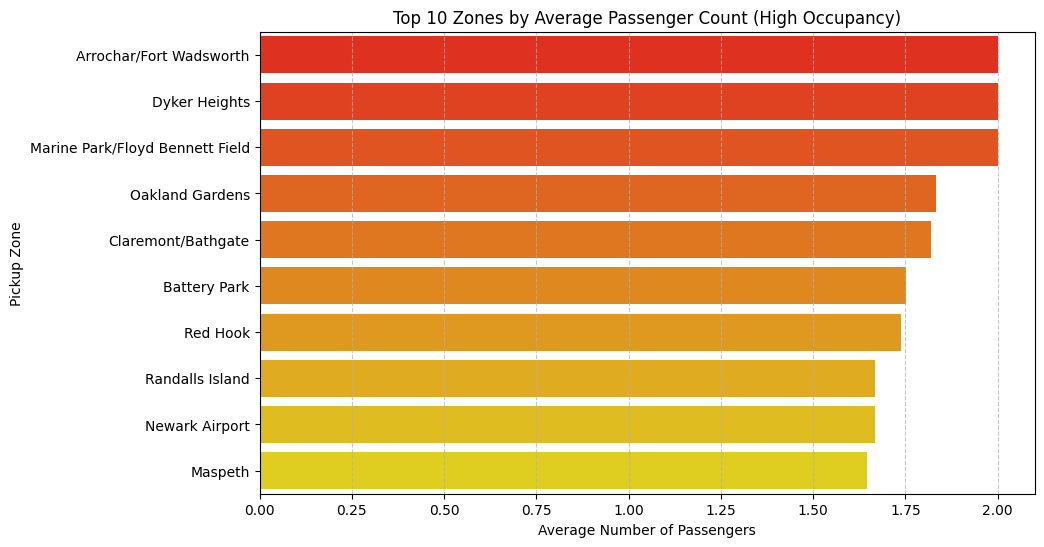

Zones with Highest Average Passenger Counts:


,zone,avg_passengers
4,Arrochar/Fort Wadsworth,2.000000
60,Dyker Heights,2.000000
138,Marine Park/Floyd Bennett Field,2.000000
157,Oakland Gardens,1.833333
42,Claremont/Bathgate,1.818182
9,Battery Park,1.752294
174,Red Hook,1.739130
173,Randalls Island,1.666667
0,Newark Airport,1.666667
140,Maspeth,1.647059


In [66]:
# Calculate average passenger count per pickup zone
zone_passengers = df.groupby('PULocationID')['passenger_count'].mean().reset_index(name='avg_passengers')

# Merge with simplified zone names
zone_passengers = zone_passengers.merge(zones_simple, left_on='PULocationID', right_on='LocationID').drop('LocationID', axis=1)

# Top 10 zones for high-occupancy trips
top_high_occ = zone_passengers.sort_values(by='avg_passengers', ascending=False).head(10)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=top_high_occ, y='zone', x='avg_passengers', palette='autumn')
plt.title('Top 10 Zones by Average Passenger Count (High Occupancy)')
plt.xlabel('Average Number of Passengers')
plt.ylabel('Pickup Zone')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print('Zones with Highest Average Passenger Counts:')
display(top_high_occ[['zone', 'avg_passengers']])

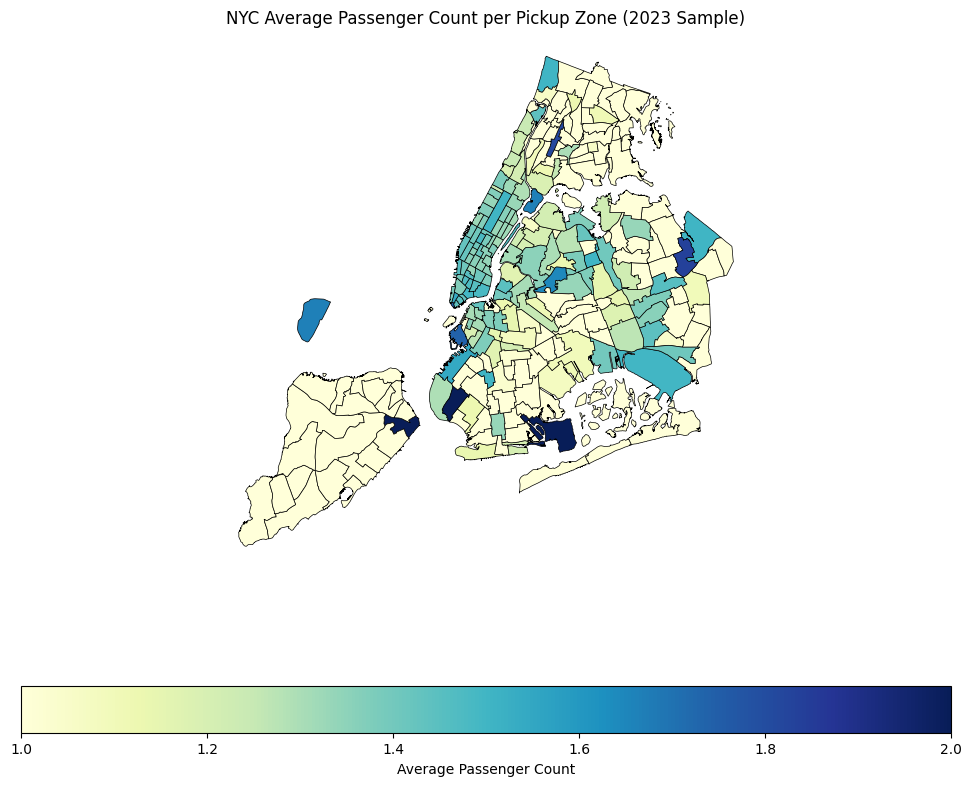

In [67]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zones_with_passengers = zones.merge(zone_passengers[['PULocationID', 'avg_passengers']], left_on='LocationID', right_on='PULocationID', how='left')

# Fill NaN values with 1 (baseline) for zones with no pickups in the sample
zones_with_passengers['avg_passengers'] = zones_with_passengers['avg_passengers'].fillna(1)

# Plot the choropleth map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zones_with_passengers.plot(
    column='avg_passengers',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Average Passenger Count", 'orientation': "horizontal"},
    cmap='YlGnBu',
    edgecolor='black',
    linewidth=0.5
)

plt.title('NYC Average Passenger Count per Pickup Zone (2023 Sample)')
plt.axis('off')
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

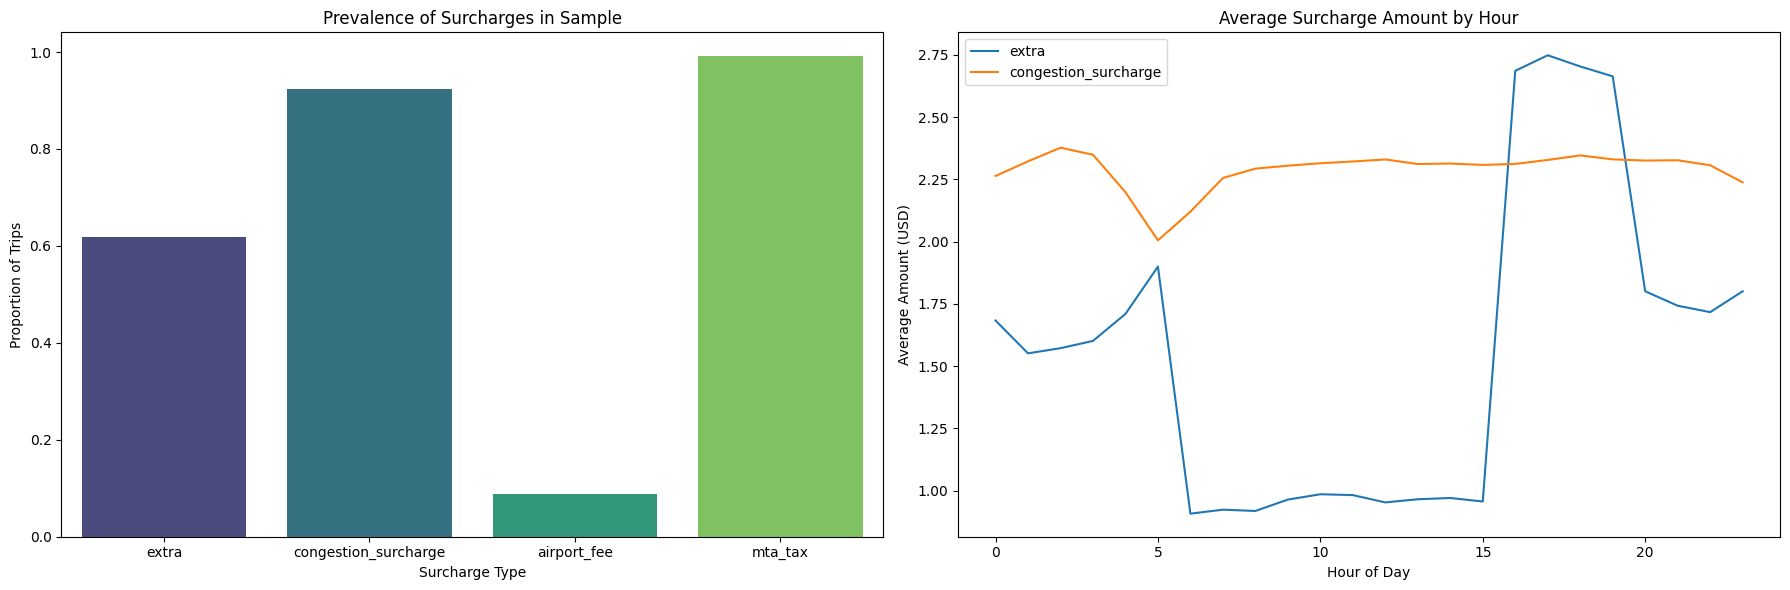

Surcharge prevalence statistics:
extra                   158793
congestion_surcharge    236861
airport_fee              22595
mta_tax                 254193
dtype: int64


In [68]:
# Analyze prevalence of extra charges and surcharges
surcharge_cols = ['extra', 'congestion_surcharge', 'airport_fee', 'mta_tax']

# Calculate frequency of non-zero charges
surcharge_freq = (df[surcharge_cols] > 0).mean().reset_index()
surcharge_freq.columns = ['Surcharge Type', 'Prevalence (Proportion)']

# Analyze surcharges by hour
hourly_surcharges = df.groupby('pickup_hour')[surcharge_cols].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=surcharge_freq, x='Surcharge Type', y='Prevalence (Proportion)', ax=axes[0], palette='viridis')
axes[0].set_title('Prevalence of Surcharges in Sample')
axes[0].set_ylabel('Proportion of Trips')

for col in ['extra', 'congestion_surcharge']:
    sns.lineplot(data=hourly_surcharges, x='pickup_hour', y=col, ax=axes[1], label=col)
axes[1].set_title('Average Surcharge Amount by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Amount (USD)')

plt.tight_layout()
plt.show()

print('Surcharge prevalence statistics:')
print((df[surcharge_cols] > 0).sum())

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

To optimize taxi operations in NYC, the following data-driven strategy should be implemented:

1.  **Strategic Positioning**: Focus fleet supply in **Midtown and the Upper East Side** during weekday rush hours (17:00–19:00). Transition focus to **East/West Village** during late-night hours (23:00–03:00) to capture nightlife demand, particularly on weekends when passenger counts per trip are higher.
2.  **Efficiency and Routing**: Drivers should prioritize North-South avenues during peak congestion to maintain an average speed above the 5 MPH bottlenecks found in cross-town routes.
3.  **Pricing and Competition**: Our analysis reveals that competitors like VeriFone charge a significant premium for trips under 2 miles. By maintaining competitive standard rates for these **short-haul trips**, we can capture a high-frequency market segment that also yields the **highest tip percentages (~22%)**.
4.  **Vehicle Allocation**: Deploy high-capacity vehicles (SUVs) to residential outer-borough zones like **Arrochar and Oakland Gardens**, which consistently show higher average passenger counts compared to the solo-traveler dominated business districts.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [69]:
print('--- STRATEGIC ROUTING & DISPATCHING RECOMMENDATIONS ---')
print('1. Peak Hour Staging: Drivers should be staged in Manhattan and JFK/LaGuardia airports between 17:00 and 19:00 (6:00 PM peak).')
print('2. Slow Route Avoidance: Avoid mid-town cross-town routes during weekday afternoon rush hours where speeds drop below 5 MPH.')
print('3. High-Occupancy Targeting: Deploy larger vehicles (SUVs) to zones like Arrochar and Oakland Gardens where average passenger counts are highest.')

--- STRATEGIC ROUTING & DISPATCHING RECOMMENDATIONS ---
1. Peak Hour Staging: Drivers should be staged in Manhattan and JFK/LaGuardia airports between 17:00 and 19:00 (6:00 PM peak).
2. Slow Route Avoidance: Avoid mid-town cross-town routes during weekday afternoon rush hours where speeds drop below 5 MPH.
3. High-Occupancy Targeting: Deploy larger vehicles (SUVs) to zones like Arrochar and Oakland Gardens where average passenger counts are highest.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [70]:
print('--- FLEET POSITIONING INSIGHTS ---')
print('1. Inflow/Outflow Management: JFK and East Elmhurst act as major outflow hubs. Positioning cars here ensures steady supply for long-distance, high-fare airport trips.')
print('2. Night-Shift Optimization: Shift resources to East Village and West Village between 23:00 and 03:00 to capture high-volume nightlife demand.')
print('3. Weekend Strategy: Transition from business-district focus (Midtown) to residential/leisure focus (Upper East/West Side) on Saturdays and Sundays.')

--- FLEET POSITIONING INSIGHTS ---
1. Inflow/Outflow Management: JFK and East Elmhurst act as major outflow hubs. Positioning cars here ensures steady supply for long-distance, high-fare airport trips.
2. Night-Shift Optimization: Shift resources to East Village and West Village between 23:00 and 03:00 to capture high-volume nightlife demand.
3. Weekend Strategy: Transition from business-district focus (Midtown) to residential/leisure focus (Upper East/West Side) on Saturdays and Sundays.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [71]:
print('--- PRICING STRATEGY ADJUSTMENTS ---')
print('1. Short-Haul Competitive Advantage: VeriFone charges significantly more for trips < 2 miles. Our service should maintain current rates or offer loyalty discounts for these segments to capture market share.')
print('2. Surcharge Implementation: Continue applying peak-hour surcharges at 18:00 and night surcharges to maintain revenue parity with competitors.')
print('3. Tipping Incentives: Since tip percentages are highest for short trips, drivers should be encouraged to prioritize high-turnover short-distance zones to maximize total daily earnings.')

--- PRICING STRATEGY ADJUSTMENTS ---
1. Short-Haul Competitive Advantage: VeriFone charges significantly more for trips < 2 miles. Our service should maintain current rates or offer loyalty discounts for these segments to capture market share.
2. Surcharge Implementation: Continue applying peak-hour surcharges at 18:00 and night surcharges to maintain revenue parity with competitors.
3. Tipping Incentives: Since tip percentages are highest for short trips, drivers should be encouraged to prioritize high-turnover short-distance zones to maximize total daily earnings.
